## Лабораторная работа № 1 
## Выполнение разведочного анализа больших данных с использованием фреймворка Apache Spark

### Часть 2

В данной части работы рассмотрены:
- разведочный анализ данных;
* работа с Dataframe API фреймворка `Apache Spark`.

Подключаем необходимые библиотеки.

In [1]:
import os
from pyspark.sql import SparkSession, DataFrame
from pyspark import SparkConf
from pyspark.sql.functions import (
    col, lit, sum, mean, when,
    explode, count, desc, floor,
    corr, array_contains, lit, first,
    stddev, trim
)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Сформируем объект конфигурации для `Apache Spark`, указав необходимые параметры.

In [2]:
def create_spark_configuration() -> SparkConf:
    """
    Создает и конфигурирует экземпляр SparkConf для приложения Spark.

    Returns:
        SparkConf: Настроенный экземпляр SparkConf.
    """
    # Получаем имя пользователя
    # Получаем имя пользователя
    user_name = os.getenv("USER")
    
    conf = SparkConf()
    conf.setAppName("Lab_1_EA")
    conf.setMaster("local[*]")
    # conf.set("spark.submit.deployMode", "client")
    conf.set("spark.executor.memory", "12g")
    conf.set("spark.executor.cores", "6")
    conf.set("spark.executor.instances", "1")
    conf.set("spark.driver.memory", "4g")
    conf.set("spark.driver.cores", "1")
    conf.set("spark.sql.catalog.spark_catalog.type", "hadoop")
    conf.set("spark.sql.catalog.spark_catalog.warehouse", f"hdfs:///b")
    conf.set("spark.sql.catalog.spark_catalog.io-impl", "org.apache.iceberg.hadoop.HadoopFileIO")

    return conf

Создаём сам объект конфигурации.

In [3]:
conf = create_spark_configuration()

Создаём и выводим на экран сессию `Apache Spark`. В процессе создания сессии происходит подключение к кластеру `Apache Hadoop`, что может занять некоторое время.

In [4]:
spark = SparkSession.builder.config(conf=conf).getOrCreate()
spark

Читаем данные.

In [5]:
database_name = "vasilev_database"
table_name = "books_table"

output_path = f"hdfs://namenode:9000/b/{database_name}/{table_name}"

df = spark.read.parquet(output_path)

Выведем прочитанную таблицу на экран.

In [6]:
df.limit(20).toPandas().style\
    .set_properties(**{'text-align': 'left', 'max-width': '0', 'white-space': 'nowrap', 'overflow': 'hidden', 'text-overflow': 'ellipsis'})\
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])\
    .format(precision=2)

,id,title,authors,publisher,published_date,categories,review_score,review_text,review_summary,review_helpfulness,review_time,user_id,profile_name,helpfulness_numerator,helpfulness_denominator,helpfulness_ratio,published_date_clean,authors_array,categories_array,published_year
0,1891882007,"""""""Breaking Traditions"""" Cathedral Windows Quick Method Quilt""","['Susan Tedrow Fisher', 'Kimberly Nappier']",Unknown,1999,['Patchwork'],4.00,"This is an interesting twist on a time-honored quilt pattern. Although I have always liked the cathedral windows pattern, I have always resisted making one due to the tremendous amount of hand sewing. This book allows you to create a beautiful quilt using machine techniques. The instructions are brief, to-the-point and clear. The illustrations appear to be hand-drawn, but they serve to explain the process and do not detract from the text. The net result is a beautiful old-style quilt streamlined for those of us who do not have the time to create it all by hand. My next full-sized project will be a cathedral window quilt.",Breaking traditions cathedral windows quick method quilt,59/61,960768000,A124LUSIP65B1U,School Librarian,59,61,0.97,None,"['Susan Tedrow Fisher', 'Kimberly Nappier']",['Patchwork'],0
1,1891882007,"""""""Breaking Traditions"""" Cathedral Windows Quick Method Quilt""","['Susan Tedrow Fisher', 'Kimberly Nappier']",Unknown,1999,['Patchwork'],3.00,"""This is not a book. It is 12 pages of instructions with hand drawn illustrations of the block units. If all you want are instructions on """"How to"""" make a traditional Cathedral Window block",Quick & Easy Instruction Sheet,31/32,1039564800,A3Q54OUHBC872L,"""G. W. Coleman """"IT Specialist""""""",31,32,0.97,None,"['Susan Tedrow Fisher', 'Kimberly Nappier']",['Patchwork'],0
2,1891882007,"""""""Breaking Traditions"""" Cathedral Windows Quick Method Quilt""","['Susan Tedrow Fisher', 'Kimberly Nappier']",Unknown,1999,['Patchwork'],1.00,"The price of this book is about 8 times what it is worth. First of all, it is not a ""paperback""; it is a ""pamphlet"". There is no firm cover or back. I feel taken advantage of when I order a book expecting a book and get a pamphlet. Some pages held together and called a ""paperback""!!!!!!!!!!!!!!!!!!!!",Got to be kidding,18/20,1083974400,A3AY8G2GT95RHL,Jacqueline Rund,18,20,0.90,None,"['Susan Tedrow Fisher', 'Kimberly Nappier']",['Patchwork'],0
3,1891882007,"""""""Breaking Traditions"""" Cathedral Windows Quick Method Quilt""","['Susan Tedrow Fisher', 'Kimberly Nappier']",Unknown,1999,['Patchwork'],5.00,"""I loved this """"book."""" The directions are excellent. The drawings are precise and provide the perfect compliment to the written directions. If you've ever wanted to make a cathedral window quilt",Horse Rider,1/1,1222041600,A1DV53Z7XEJEY7,"""Horse Rider """"ET""""""",1,1,1.00,None,"['Susan Tedrow Fisher', 'Kimberly Nappier']",['Patchwork'],0
4,B000PH26B4,"""""""Dear America"""" Four Volume Boxed Set (Dear America)""",Dear America: Standing in the Light,['Scholastic Books'],None,Unknown,5.00,my daughter will be so surprised on christmas morning and im so glad i found what i was looking for for such a good price. I recieved it and its perfect!,happy,0/0,1354924800,A2D99F1RC3ZCVI,cindy bancroft,0,0,0.00,None,[' Dear America: Standing in the Light'],None,0
5,0898702755,"""""""Forget Not Love"""": The Passion of Maximilian Kolbe""",['André Frossard'],Ignatius Press,1991,['Religion'],5.00,"""Forget Not Love"" is the story of St. Maximilian Kolbe, the Polish Franciscan who offered to die in the place of a married man at Auschwitz, yet this book is about so much more. It creates a portrait of Kolbe as a real human being, it tells of one man's zeal for his faith and country, and it is about what love really is. This book is one of the best I have read on St. Maximilian. Frossard's beautiful writing is an added plus. I HIGHLY reccomend this book to all!","""Forget Not Love"" is Special",43/44,932342400,None

Посмотрим на схему данных.

In [7]:
df.printSchema()

root
 |-- id: string (nullable = true)
 |-- title: string (nullable = true)
 |-- authors: string (nullable = true)
 |-- publisher: string (nullable = true)
 |-- published_date: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- review_score: double (nullable = true)
 |-- review_text: string (nullable = true)
 |-- review_summary: string (nullable = true)
 |-- review_helpfulness: string (nullable = true)
 |-- review_time: integer (nullable = true)
 |-- user_id: string (nullable = true)
 |-- profile_name: string (nullable = true)
 |-- helpfulness_numerator: integer (nullable = true)
 |-- helpfulness_denominator: integer (nullable = true)
 |-- helpfulness_ratio: double (nullable = true)
 |-- published_date_clean: date (nullable = true)
 |-- authors_array: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- categories_array: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- published_year: integer (nullable = true)



Вычислим количество строк в датафрейме.

In [8]:
df.count()

2999829

### Анализ отзывов и рейтингов

#### Служебные функции

In [9]:
def count_nulls(data: DataFrame,
                column_name: str) -> None:
    """
    Подсчет количества null и not null значений в указанном столбце.

    Args:
        data (DataFrame): DataFrame, содержащий данные.
        column_name (str): Имя столбца для подсчета null и not null значений.
    
    Returns:
        None
    """
    # Подсчет количества null значений в указанном столбце
    null_counts = data.select(
        sum(col(column_name).isNull().cast("int"))
    ).collect()[0][0]

    # Подсчет количества not null значений в указанном столбце
    not_null_counts = data.select(
        sum(col(column_name).isNotNull().cast("int"))
    ).collect()[0][0]

    # Вывод результатов
    print(f"Число колонок с NULL: {null_counts} "
          f"({100 * null_counts / (null_counts + not_null_counts):.2f}%)")


In [10]:
def plot_cat_distribution(data: DataFrame,
                          column_name: str,
                          top_n: int = 20) -> None:
    """
    Построение распределения категориального признака.

    Args:
        data (DataFrame): DataFrame, содержащий данные.
        column_name (str): Имя столбца для группировки.
        top_n (int): Количество топ-значений для отображения.
    
    Returns:
        None
    """
    # Группировка данных по столбцу и подсчет количества
    categories = (
        data
        .groupBy(column_name)
        .count()
        .orderBy("count", ascending=False)
    )
    
    print(f"Количество категорий признака {column_name}: {categories.count()}")

    categories = (
        categories
        .limit(top_n)
        .toPandas()
    )
    
    # Визуализация с использованием Seaborn
    plt.figure(figsize=(10, 6))
    sns.barplot(x=column_name, y="count", data=categories)
    plt.title(f"Barplot of \"{column_name}\" counts")
    plt.xlabel(column_name)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

In [11]:
def plot_boxplots(data: DataFrame,
                  columns: list[str],
                  sample_fraction: float = 0.1) -> None:
    """
    Построение boxplot для нескольких столбцов в PySpark DataFrame.

    Args:
        data (DataFrame): DataFrame, содержащий данные.
        columns (list of str): Список имен столбцов для построения boxplot.
        sample_fraction (float): Доля данных для семплирования выбросов.
    
    Returns:
        None
    """
    box_data = []

    for column in columns:
        # Вычисление квантилей
        quantiles = data.approxQuantile(column, [0.25, 0.5, 0.75], 0.01)
        q1, median, q3 = quantiles

        # Вычисление IQR и границ усов
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Получаем минимальное и максимальное значения как числа Python
        min_value = float(data.agg({column: "min"}).collect()[0][0])
        max_value = float(data.agg({column: "max"}).collect()[0][0])
        mean_value = float(data.agg({column: "mean"}).collect()[0][0])
        std_value = float(data.agg({column: "std"}).collect()[0][0])

        # Ограничение усов минимальным и максимальным значениями (используем встроенный max/min)
        lower_bound = max(lower_bound, min_value)  # Теперь это числа Python
        upper_bound = min(upper_bound, max_value)  # Теперь это числа Python

        # Фильтрация выбросов
        outliers_df = data.filter((col(column) < lower_bound) | (col(column) > upper_bound))

        # Семплирование выбросов
        outliers = []
        if not outliers_df.isEmpty():
            sampled_outliers_df = outliers_df.sample(sample_fraction)
            outliers = (
                sampled_outliers_df
                .select(column)
                .limit(1000)
                .rdd.flatMap(lambda x: x)
                .collect()
            )
            
            # Добавление минимального и максимального значений, если они 
            # относятся к выбросам и не присутствуют в семпле
            if min_value < lower_bound and min_value not in outliers:
                outliers.append(min_value)
            if max_value > upper_bound and max_value not in outliers:
                outliers.append(max_value)

        # Подготовка данных для axes.bxp
        box_data.append({
            'whislo': lower_bound,  # Нижняя граница усов
            'q1': q1,               # Первый квартиль
            'med': median,          # Медиана
            'q3': q3,               # Третий квартиль
            'whishi': upper_bound,  # Верхняя граница усов
            'fliers': outliers      # Выбросы
        })
        
        # Вывод статистических характеристик для каждого столбца
        print(f"\n=== СТАТИСТИКА ДЛЯ {column} ===")
        print(f"Минимальное значение:          {min_value:.2f}")
        print(f"Среднее значение:              {mean_value:.2f}")
        print(f"Среднеквадратичное отклонение: {std_value:.2f}")
        print(f"Первый квартиль:               {q1:.2f}")
        print(f"Медиана:                       {median:.2f}")
        print(f"Третий квартиль:               {q3:.2f}")
        print(f"Максимальное значение:         {max_value:.2f}")
        print(f"Нижняя граница усов:          {lower_bound:.2f}")
        print(f"Верхняя граница усов:         {upper_bound:.2f}")
        print(f"Количество выбросов:          {len(outliers)}")

    # Построение boxplot
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.bxp(box_data, 
           vert=False, 
           positions=range(1, len(columns) + 1), widths=0.5)
    ax.set_yticks(range(1, len(columns) + 1))
    ax.set_yticklabels(columns)
    ax.set_xlabel('Value')
    ax.set_title('Boxplots')
    ax.grid(True)
    plt.show()

In [12]:
def plot_quant_distribution(data: DataFrame,
                            column: str,
                            num_bins: int = 200) -> None:
    """
    Построение гистограммы для количественной переменной с 
    использованием PySpark и Seaborn.

    Args:
        data (DataFrame): DataFrame с данными.
        column_name (str): Название колонки с количественной переменной.
        num_bins (int): Количество бинов для гистограммы.

    Returns:
        None
    """
    # Находим минимальное и максимальное значения колонки
    min_value = data.agg({column: "min"}).collect()[0][0]
    max_value = data.agg({column: "max"}).collect()[0][0]

    # Размер бина
    bin_size = (max_value - min_value) / num_bins

    # Добавляем колонку с номером бина
    data = data.withColumn(
        "bin", 
        floor((col(column) - min_value) / bin_size)
    )

    # Группируем по номеру бина и считаем количество строк в каждом бине
    bin_counts = data.groupBy("bin").count()

    # Преобразуем результат в Pandas DataFrame для построения гистограммы
    bin_counts_pd = bin_counts.limit(1000).toPandas()
    
    # Создаем массив границ бинов
    bin_edges = [min_value + i * bin_size for i in range(num_bins + 2)]
    
    # Преобразуем номера бинов в центры бинов
    bin_centers = [
        (bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(num_bins + 1)
    ]
    
    # Добавляем центры бинов в Pandas DataFrame
    bin_counts_pd['bin_center'] = bin_counts_pd['bin'].apply(
        lambda x: bin_centers[int(x)]
    )
    
    # Построение гистограммы с использованием Seaborn
    plt.figure(figsize=(20, 6))
    sns.histplot(data=bin_counts_pd, x="bin_center", 
                 weights="count", kde=True, bins=num_bins + 1)
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.title(f"Распределение количественного признака \"{column}\"")
    plt.grid(True)
    plt.show()

In [13]:
def print_df(df):
    return df.limit(20).toPandas().style\
    .set_properties(**{'text-align': 'left', 'max-width': '0', 'white-space': 'nowrap', 'overflow': 'hidden', 'text-overflow': 'ellipsis'})\
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])\
    .format(precision=2)

#### Анализ столбца `id`

Отсортируем датафрейм по столбцу `id`, который может рассматриваться в качестве первичного ключа таблицы.

In [14]:
col_name = "id"
print_df(df.orderBy(col_name, ascending=False))

,id,title,authors,publisher,published_date,categories,review_score,review_text,review_summary,review_helpfulness,review_time,user_id,profile_name,helpfulness_numerator,helpfulness_denominator,helpfulness_ratio,published_date_clean,authors_array,categories_array,published_year
0,B0064P287I,"""Rush: Time Machine 2011 - Live in Cleveland (Blu-ray + XL """"Rash"""" T-Shirt Box Set) [Blu-ray]""","['George Keate', 'George Kingesby']",Unknown,1760,['English poetry'],5.00,"Things to consider:Rush: Time Machine 2011 - Live in Cleveland [Blu-ray]-Probably the best all-around set list to be put on a live video (subjectively)-The audio/video sync issues that you saw in R30 and Rush in Rio are no more!-The audio and video quality is much better than before. The audio mixing is much more oriented to a home theatre.-The camera angles and editing are a lot better than previous live video, with better movement and fewer static shots.-A lot of good crowd shots mixed in to really bring that energy for the viewer up-Includes all of the shorts prior to the songs which are a lot of fun.This is a great blu-ray. If you are a Rush fan or even just a music fan you will really enjoy showing off your system to others with this.-Cory",They have struggled with live DVD/Blu-Ray until now,1/1,1355961600,A2KW8A5RVLDDZO,Cory,1,1,1.00,None,"['George Keate', 'George Kingesby']",['English poetry'],0
1,B0064P287I,"""Rush: Time Machine 2011 - Live in Cleveland (Blu-ray + XL """"Rash"""" T-Shirt Box Set) [Blu-ray]""","['George Keate', 'George Kingesby']",Unknown,1760,['English poetry'],5.00,"""I'm 29 and I don't see me rocking 30 years from now like these guys do. The filming is great, the animations are fun, and the music is incredible... well, it's Rush, playing Moving Pictures entirely 30 years after it's release, playing songs like Stick It Out, Subdivisions and Presto, just to name a few... and breaking your face while playing Working Man.Well, I don't know why I wrote all this stuff, just the """"It's Rush"""" was enough",They're almost 60. They're almost gods.,0/0,1344297600,A2ZXINSO6P5OL5,Gabriel Scudelari-Abilio,0,0,0.00,None,"['George Keate', 'George Kingesby']",['English poetry'],0
2,B0064P287I,"""Rush: Time Machine 2011 - Live in Cleveland (Blu-ray + XL """"Rash"""" T-Shirt Box Set) [Blu-ray]""","['George Keate', 'George Kingesby']",Unknown,1760,['English poetry'],5.00,"Rush fans already know the level of performance that the band is famous for. I have been a fan since the 70's and they never have let me down and never cease to amaze me. However, the performance on this night in Cleveland is magic beyond words. Those who know the history of Rush know the significance of the city of Cleveland to the band. From three rock icons who are pushing 60 years of age this performance proves that age means nothing. They just keep defying their critics and defying the odds.The production on Blu Ray is top notch. Get this one soon so when you've worn it out there will still be more available!Hats off (once again) to Neil, Alex and Geddy for another in a long line of stellar performances. Oh and the 'alternate versions' of SoR are worth the price of admission alone!",The Best Yet From The Best,1/1,1353801600,A1UBUZFYZ0T9YK,jmoonx14,1,1,1.00,None,"['George Keate', 'George Kingesby']",['English poetry'],0
3,B0064P287I,"""Rush: Time Machine 2011 - Live in Cleveland (Blu-ray + XL """"Rash"""" T-Shirt Box Set) [Blu-ray]""","['George Keate', 'George Kingesby']",Unknown,1760,['English poetry'],5.00,"""I am mystified as to why the person who wrote the most """"helpful critical review"""" had such a problem with the sound mix of the fantastic Blu-Ray. As Rush has progressed over the years when it comes to releasing their concert video's",The BEST DVD Rush has ever produced!!!,4/5,1320969600,A1WYNL7HQUYLKO,William J. Gutierrez,4,5,0.80,None,"['George Keate', 'George Kingesby']",['English poetry'],0
4,B0064P287I,"""Rush: Time Machine 2011 - Live in Cleveland (Blu-ray + XL """"Ra

Видно, что идентификаторы имеют разный формат. Обычно ISBN состоит из 10 или 13 цифр, ASIN - из 10 символов. Отфильтруем корректные идентификаторы.

In [15]:
# Регулярные выражения для ISBN-10, ISBN-13 и ASIN
isbn10_pattern = r"^\d{9}[\dX]$"
isbn13_pattern = r"^\d{13}$"
asin_pattern = r"^[A-Z0-9]{10}$"

# Фильтрация DataFrame по корректным идентификаторам
df = df.filter(
    col(col_name).rlike(isbn10_pattern) | 
    col(col_name).rlike(isbn13_pattern) | 
    col(col_name).rlike(asin_pattern)
)
print_df(df)

,id,title,authors,publisher,published_date,categories,review_score,review_text,review_summary,review_helpfulness,review_time,user_id,profile_name,helpfulness_numerator,helpfulness_denominator,helpfulness_ratio,published_date_clean,authors_array,categories_array,published_year
0,1891882007,"""""""Breaking Traditions"""" Cathedral Windows Quick Method Quilt""","['Susan Tedrow Fisher', 'Kimberly Nappier']",Unknown,1999,['Patchwork'],4.00,"This is an interesting twist on a time-honored quilt pattern. Although I have always liked the cathedral windows pattern, I have always resisted making one due to the tremendous amount of hand sewing. This book allows you to create a beautiful quilt using machine techniques. The instructions are brief, to-the-point and clear. The illustrations appear to be hand-drawn, but they serve to explain the process and do not detract from the text. The net result is a beautiful old-style quilt streamlined for those of us who do not have the time to create it all by hand. My next full-sized project will be a cathedral window quilt.",Breaking traditions cathedral windows quick method quilt,59/61,960768000,A124LUSIP65B1U,School Librarian,59,61,0.97,None,"['Susan Tedrow Fisher', 'Kimberly Nappier']",['Patchwork'],0
1,1891882007,"""""""Breaking Traditions"""" Cathedral Windows Quick Method Quilt""","['Susan Tedrow Fisher', 'Kimberly Nappier']",Unknown,1999,['Patchwork'],3.00,"""This is not a book. It is 12 pages of instructions with hand drawn illustrations of the block units. If all you want are instructions on """"How to"""" make a traditional Cathedral Window block",Quick & Easy Instruction Sheet,31/32,1039564800,A3Q54OUHBC872L,"""G. W. Coleman """"IT Specialist""""""",31,32,0.97,None,"['Susan Tedrow Fisher', 'Kimberly Nappier']",['Patchwork'],0
2,1891882007,"""""""Breaking Traditions"""" Cathedral Windows Quick Method Quilt""","['Susan Tedrow Fisher', 'Kimberly Nappier']",Unknown,1999,['Patchwork'],1.00,"The price of this book is about 8 times what it is worth. First of all, it is not a ""paperback""; it is a ""pamphlet"". There is no firm cover or back. I feel taken advantage of when I order a book expecting a book and get a pamphlet. Some pages held together and called a ""paperback""!!!!!!!!!!!!!!!!!!!!",Got to be kidding,18/20,1083974400,A3AY8G2GT95RHL,Jacqueline Rund,18,20,0.90,None,"['Susan Tedrow Fisher', 'Kimberly Nappier']",['Patchwork'],0
3,1891882007,"""""""Breaking Traditions"""" Cathedral Windows Quick Method Quilt""","['Susan Tedrow Fisher', 'Kimberly Nappier']",Unknown,1999,['Patchwork'],5.00,"""I loved this """"book."""" The directions are excellent. The drawings are precise and provide the perfect compliment to the written directions. If you've ever wanted to make a cathedral window quilt",Horse Rider,1/1,1222041600,A1DV53Z7XEJEY7,"""Horse Rider """"ET""""""",1,1,1.00,None,"['Susan Tedrow Fisher', 'Kimberly Nappier']",['Patchwork'],0
4,B000PH26B4,"""""""Dear America"""" Four Volume Boxed Set (Dear America)""",Dear America: Standing in the Light,['Scholastic Books'],None,Unknown,5.00,my daughter will be so surprised on christmas morning and im so glad i found what i was looking for for such a good price. I recieved it and its perfect!,happy,0/0,1354924800,A2D99F1RC3ZCVI,cindy bancroft,0,0,0.00,None,[' Dear America: Standing in the Light'],None,0
5,0898702755,"""""""Forget Not Love"""": The Passion of Maximilian Kolbe""",['André Frossard'],Ignatius Press,1991,['Religion'],5.00,"""Forget Not Love"" is the story of St. Maximilian Kolbe, the Polish Franciscan who offered to die in the place of a married man at Auschwitz, yet this book is about so much more. It creates a portrait of Kolbe as a real human being, it tells of one man's zeal for his faith and country, and it is about what love really is. This book is one of the best I have read on St. Maximilian. Frossard's beautiful writing is an added plus. I HIGHLY reccomend this book to all!","""Forget Not Love"" is Special",43/44,932342400,None

In [16]:
df.count()

2999829

Проверим наличие дубликатов в датафрейме.

In [17]:
(
    df
    .groupBy(col_name)
    .count()
    .where("count > 1")
    .orderBy("count", ascending=False)
    .show()
)

+----------+-----+
|        id|count|
+----------+-----+
|B000IEZE3G| 6796|
|B000ILIJE0| 4438|
|B000GQG7D2| 4428|
|B000GQG5MA| 4427|
|B000NDSX6C| 4426|
|B000NWU3I4| 4420|
|B000PC54NG| 4402|
|B000NWQXBA| 4397|
|B000Q032UY| 4373|
|B000H9R1Q0| 4370|
|B0000YSH4W| 3822|
|B000P1QRII| 3822|
|B0000YSH5G| 3568|
|B000PCESRE| 3280|
|B000PMCF1A| 3270|
|B000I3NFKG| 3260|
|B000PWMT1G| 3150|
|B000MOOAJG| 3145|
|B000NPEWHE| 3137|
|B000J521DU| 3137|
+----------+-----+
only showing top 20 rows



Дубликаты есть. Посмотрим, что они собой представляют (на примере одной записи).

In [18]:
duplicate_ids = df.groupBy(col_name).count().where("count > 1").limit(5)
if duplicate_ids.count() > 0:
    sample_duplicate = duplicate_ids.first()[col_name]
    print_df(df.filter(col(col_name) == sample_duplicate))

Похоже на полную идентичность строк. Трогать не имеет смысла.

#### Анализ столбца `title`

Данный столбец содержит названия книг и представляет собой **текстовый признак**. Проверим его на наличие пропущенных значений и проанализируем распределение.

In [19]:
col_name = "title"
count_nulls(data=df, column_name=col_name)

Число колонок с NULL: 0 (0.00%)


Видно, что пропусков нет.

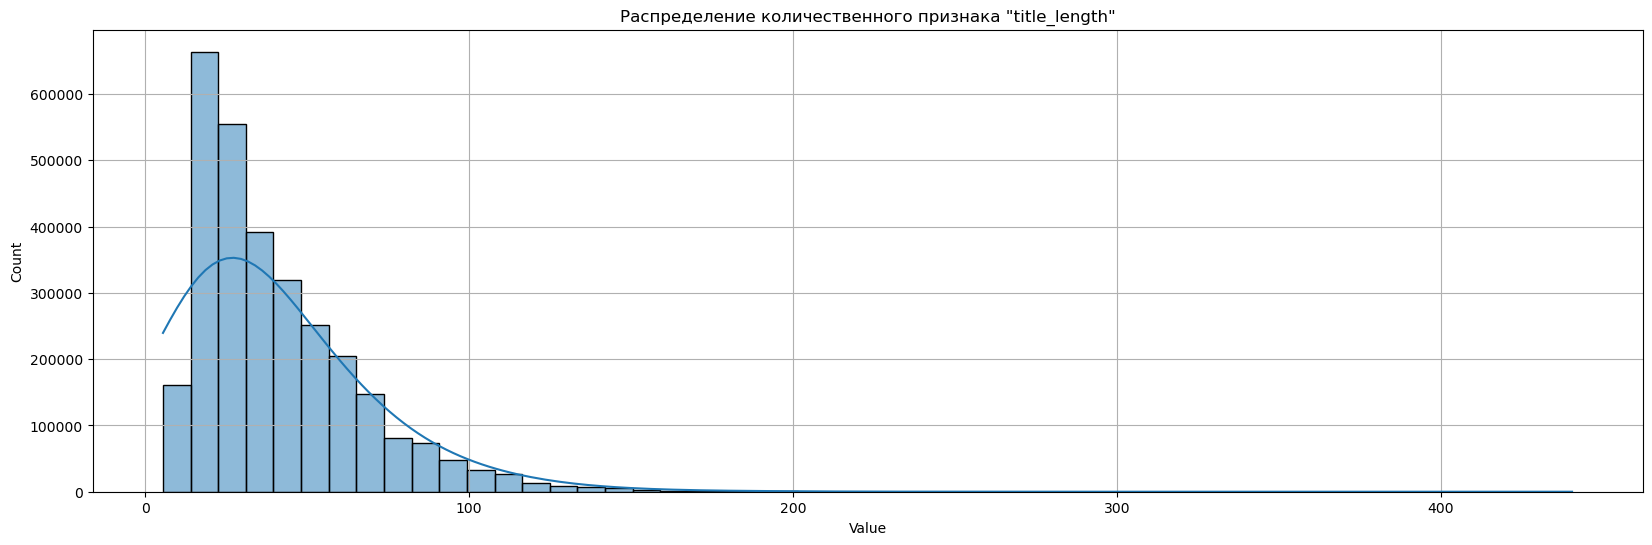

In [20]:
# Посмотрим на распределение длин названий
from pyspark.sql.functions import length

df_with_title_length = df.withColumn("title_length", length(col_name))
plot_quant_distribution(data=df_with_title_length, column="title_length", num_bins=50)

Проанализируем самые частые названия

Количество категорий признака title: 212399


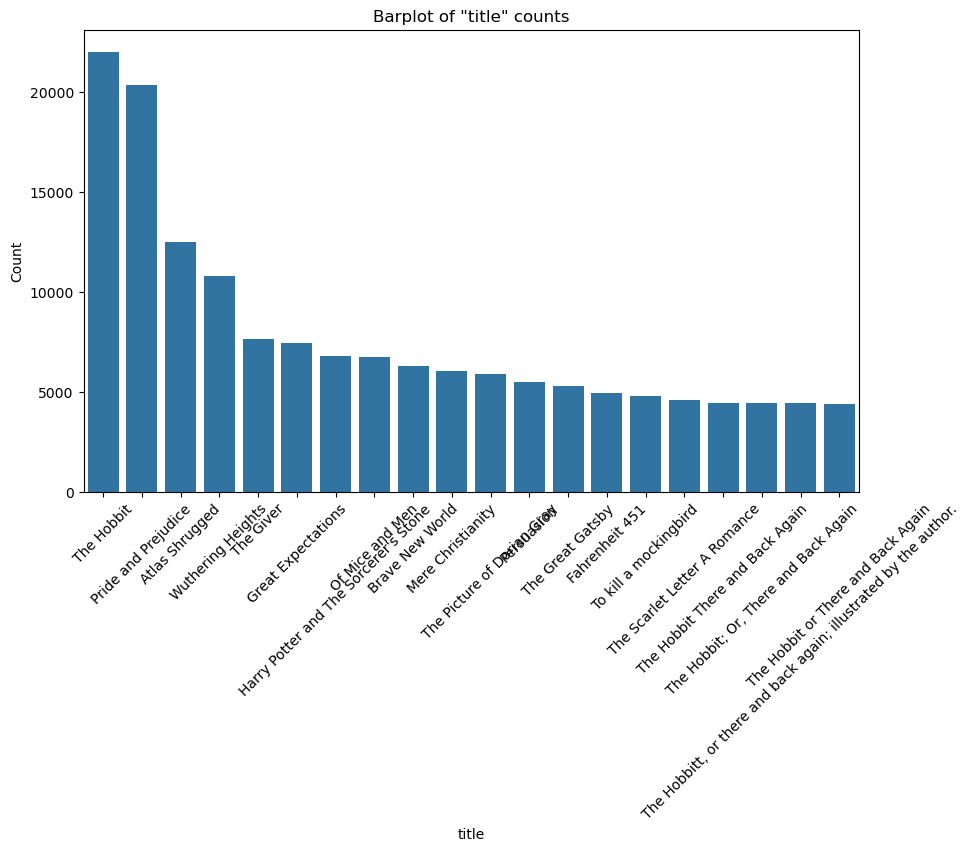

In [21]:
plot_cat_distribution(data=df, column_name=col_name, top_n=20)

Проверим наличие дубликатов названий

In [22]:
print("Статистика по дубликатам названий:")
(
    df
    .groupBy(col_name)
    .count()
    .where("count > 1")
    .orderBy("count", ascending=False)
    .show(10, truncate=False)
)

Статистика по дубликатам названий:
+-------------------------------------+-----+
|title                                |count|
+-------------------------------------+-----+
|The Hobbit                           |22023|
|Pride and Prejudice                  |20371|
|Atlas Shrugged                       |12513|
|Wuthering Heights                    |10780|
|The Giver                            |7644 |
|Great Expectations                   |7421 |
|Harry Potter and The Sorcerer's Stone|6796 |
|Of Mice and Men                      |6728 |
|Brave New World                      |6312 |
|Mere Christianity                    |6053 |
+-------------------------------------+-----+
only showing top 10 rows



Посмотрим на примеры книг с одинаковыми названиями

In [23]:
duplicate_titles = (
    df
    .groupBy(col_name)
    .count()
    .where("count > 1")
    .orderBy("count", ascending=False)
    .limit(3)
)

for row in duplicate_titles.collect():
    title = row[col_name]
    print(f"\nКниги с названием: '{title}'")
    df.filter(col(col_name) == title).select("id", "authors", "publisher").show(truncate=False)


Книги с названием: 'The Hobbit'
+----------+--------------------+-------------+
|id        |authors             |publisher    |
+----------+--------------------+-------------+
|B000NDSX6C|['J. R. R. Tolkien']|Mariner Books|
|B000NDSX6C|['J. R. R. Tolkien']|Mariner Books|
|B000NDSX6C|['J. R. R. Tolkien']|Mariner Books|
|B000NDSX6C|['J. R. R. Tolkien']|Mariner Books|
|B000NDSX6C|['J. R. R. Tolkien']|Mariner Books|
|B000NDSX6C|['J. R. R. Tolkien']|Mariner Books|
|B000NDSX6C|['J. R. R. Tolkien']|Mariner Books|
|B000NDSX6C|['J. R. R. Tolkien']|Mariner Books|
|B000NDSX6C|['J. R. R. Tolkien']|Mariner Books|
|B000NDSX6C|['J. R. R. Tolkien']|Mariner Books|
|B000NDSX6C|['J. R. R. Tolkien']|Mariner Books|
|B000NDSX6C|['J. R. R. Tolkien']|Mariner Books|
|B000NDSX6C|['J. R. R. Tolkien']|Mariner Books|
|B000NDSX6C|['J. R. R. Tolkien']|Mariner Books|
|B000NDSX6C|['J. R. R. Tolkien']|Mariner Books|
|B000NDSX6C|['J. R. R. Tolkien']|Mariner Books|
|B000NDSX6C|['J. R. R. Tolkien']|Mariner Books|
|B000ND

In [24]:
# Анализ специальных символов в названиях
print("Названия с кавычками в начале:")
df.filter(col(col_name).startswith('"')).select(col_name).show(10, truncate=False)

print("Названия с HTML-символами:")
df.filter(col(col_name).contains("&quot;") | col(col_name).contains("&amp;")).select(col_name).show(10, truncate=False)

Названия с кавычками в начале:
+--------------------------------------------------------------+
|title                                                         |
+--------------------------------------------------------------+
|"""Breaking Traditions"" Cathedral Windows Quick Method Quilt"|
|"""Breaking Traditions"" Cathedral Windows Quick Method Quilt"|
|"""Breaking Traditions"" Cathedral Windows Quick Method Quilt"|
|"""Breaking Traditions"" Cathedral Windows Quick Method Quilt"|
|"""Dear America"" Four Volume Boxed Set (Dear America)"       |
|"""Forget Not Love"": The Passion of Maximilian Kolbe"        |
|"""Forget Not Love"": The Passion of Maximilian Kolbe"        |
|"""Forget Not Love"": The Passion of Maximilian Kolbe"        |
|"""Forget Not Love"": The Passion of Maximilian Kolbe"        |
|"""Forget Not Love"": The Passion of Maximilian Kolbe"        |
+--------------------------------------------------------------+
only showing top 10 rows

Названия с HTML-символами:
+-----

In [25]:
# Статистика по названиям
print("Общая статистика по столбцу Title:")
print(f"Уникальных названий: {df.select(col_name).distinct().count()}")
print(f"Всего записей: {df.count()}")
print(f"Процент уникальных названий: {100 * df.select(col_name).distinct().count() / df.count():.2f}%")

Общая статистика по столбцу Title:
Уникальных названий: 212399
Всего записей: 2999829
Процент уникальных названий: 7.08%


#### Анализ столбца `review_score`

Данный столбец содержит оценки книг пользователями и представляет собой **количественный признак**. Проанализируем распределение оценок и наличие пропущенных значений.

In [26]:
col_name = "review_score"
df.select(col_name).orderBy(col_name, ascending=False).show(10)
df.select(col_name).orderBy(col_name, ascending=True).show(10)

+------------+
|review_score|
+------------+
|  1.295568E9|
|   1.21176E9|
|   1.21176E9|
| 1.2089952E9|
|       327.0|
|       327.0|
|       327.0|
|       327.0|
|       327.0|
|       19.95|
+------------+
only showing top 10 rows

+------------+
|review_score|
+------------+
|         0.0|
|         0.0|
|         0.0|
|         0.0|
|         0.0|
|         0.0|
|         0.0|
|         0.0|
|         0.0|
|         0.0|
+------------+
only showing top 10 rows



In [27]:
from pyspark.sql.functions import (min as mn, max as mx)


rating_stats = df.select(
    count(col_name).alias("total_reviews"),
    mean(col_name).alias("avg_rating"),
    stddev(col_name).alias("std_rating"),
    mn(col_name).alias("min_rating"),
    mx(col_name).alias("max_rating"),
    count(when(col(col_name).isNull(), True)).alias("null_ratings"),
    count(when(col(col_name) == 5.0, True)).alias("five_star_count"),
    count(when(col(col_name) == 1.0, True)).alias("one_star_count")
).collect()[0]

print("=== БАЗОВАЯ СТАТИСТИКА ОЦЕНОК ===")
print(f"Всего оценок: {rating_stats['total_reviews']:,}")
print(f"Пропущенных оценок: {rating_stats['null_ratings']}")
print(f"Средняя оценка: {rating_stats['avg_rating']:.2f} ⭐")
print(f"Стандартное отклонение: {rating_stats['std_rating']:.2f}")
print(f"Диапазон оценок: {rating_stats['min_rating']} - {rating_stats['max_rating']}")
print(f"5-звездочных оценок: {rating_stats['five_star_count']:,}")
print(f"1-звездочных оценок: {rating_stats['one_star_count']:,}")

=== БАЗОВАЯ СТАТИСТИКА ОЦЕНОК ===
Всего оценок: 2,999,829
Пропущенных оценок: 0
Средняя оценка: 1646.98 ⭐
Стандартное отклонение: 1423286.19
Диапазон оценок: 0.0 - 1295568000.0
5-звездочных оценок: 1,795,640
1-звездочных оценок: 200,993


In [28]:
count_nulls(data=df, column_name=col_name)

Число колонок с NULL: 0 (0.00%)


Отчистка данных

In [29]:
 # Анализ до очистки
total_before = df.count()
print(f"Всего записей до очистки: {total_before:,}")

# Находим аномальные значения
anomalous = df.filter(
    (col(col_name) < 1.0) | (col(col_name) > 5.0)
)

print(f"Найдено аномальных оценок: {anomalous.count():,}")

if anomalous.count() > 0:
    print("\nПримеры аномальных значений:")
    anomalous.select("id", "title", col_name).show(10)
    
    # Анализ распределения аномальных значений
    print("Распределение аномальных значений:")
    anomalous.groupBy(col_name).count().orderBy(col_name).show(20)

# Фильтруем только корректные оценки (1.0 - 5.0)
df = df.filter(
    (col(col_name) >= 1.0) & (col(col_name) <= 5.0)
)

# Также убираем пропуски
df = df.filter(col(col_name).isNotNull())

total_after = df.count()
removed_count = total_before - total_after

print(f"\nРезультаты очистки:")
print(f"Удалено записей: {removed_count:,} ({removed_count/total_before*100:.2f}%)")
print(f"Осталось записей: {total_after:,} ({total_after/total_before*100:.2f}%)")
count_nulls(data=df, column_name=col_name)

Всего записей до очистки: 2,999,829
Найдено аномальных оценок: 18,113

Примеры аномальных значений:
+----------+-----------------+------------+
|        id|            title|review_score|
+----------+-----------------+------------+
|1841769231|  """Landing Ship|         0.0|
|1841769231|  """Landing Ship|         0.0|
|1841769231|  """Landing Ship|         0.0|
|1841769231|  """Landing Ship|         0.0|
|1841769231|  """Landing Ship|         0.0|
|0688156347|"""More More More|         0.0|
|0688156347|"""More More More|         0.0|
|0688156347|"""More More More|         0.0|
|0688156347|"""More More More|         0.0|
|0688156347|"""More More More|         0.0|
+----------+-----------------+------------+
only showing top 10 rows

Распределение аномальных значений:
+------------+-----+
|review_score|count|
+------------+-----+
|         0.0|18089|
|       19.95|   15|
|       327.0|    5|
| 1.2089952E9|    1|
|   1.21176E9|    2|
|  1.295568E9|    1|
+------------+-----+


Результаты 

BOXPLOT ДЛЯ АНАЛИЗА ВЫБРОСОВ


=== СТАТИСТИКА ДЛЯ review_score ===
Минимальное значение:          1.00
Среднее значение:              4.21
Среднеквадратичное отклонение: 1.20
Первый квартиль:               4.00
Медиана:                       5.00
Третий квартиль:               5.00
Максимальное значение:         5.00
Нижняя граница усов:          2.50
Верхняя граница усов:         5.00
Количество выбросов:          1000


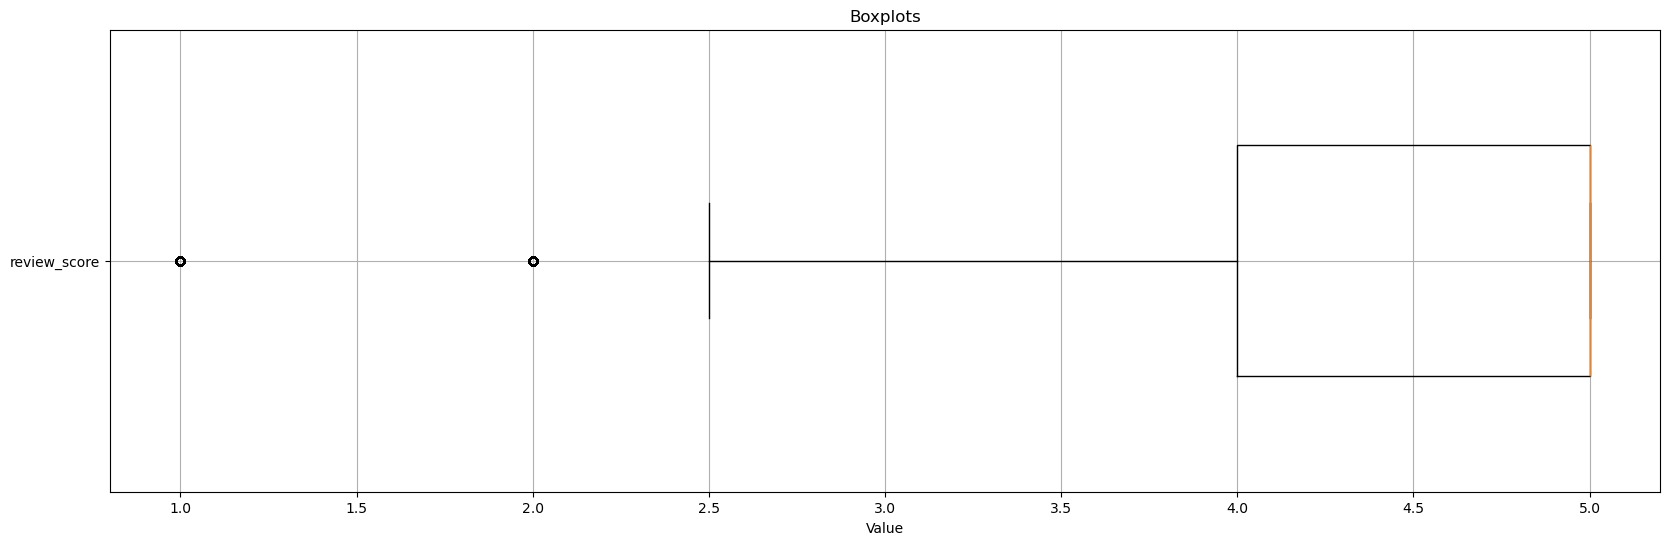

In [30]:
plot_boxplots(df, [col_name])

ГИСТОГРАММА РАСПРЕДЕЛЕНИЯ

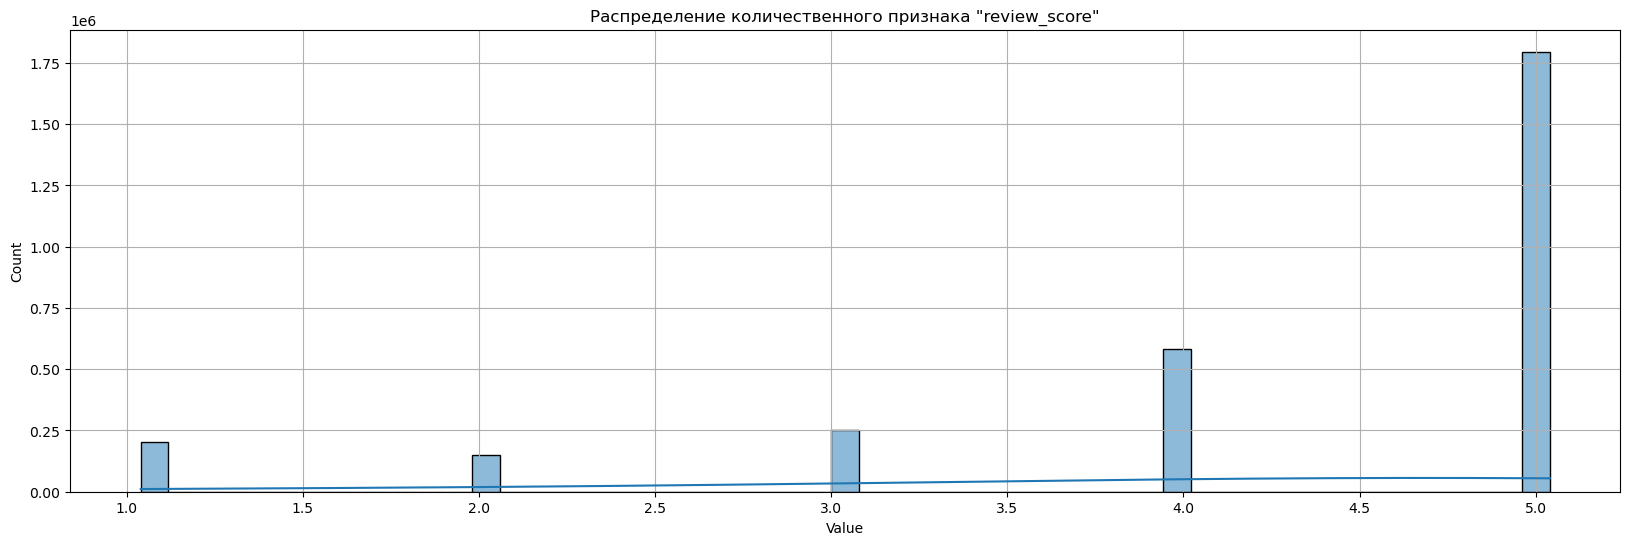

In [31]:
plot_quant_distribution(df, col_name, num_bins=50)

#### Анализ столбца `review_text`

Данный столбец содержит текст отзыва и представляет собой **текстовой признак**. Проанализируем текста и наличие пропущенных значений.

In [32]:
col_name = "review_text"
df.select(col_name).orderBy(col_name, ascending=False).show(10)
df.select(col_name).orderBy(col_name, ascending=True).show(10)

+--------------------+
|         review_text|
+--------------------+
|~~~~~~~~~~~~~~~~~...|
|~~~~~Good:1) Many...|
|~~~~~Dull and bor...|
|~~~This book is a...|
|~~~Karnow's book ...|
|~~~Engineering an...|
|~~~Author Connnel...|
|~~~Arendt's Criti...|
|~~~Arendt's Criti...|
|~~~A Scholarly Ge...|
+--------------------+
only showing top 10 rows

+--------------------+
|         review_text|
+--------------------+
|                    |
|                    |
|                    |
|                    |
|                    |
|                    |
|                    |
|                    |
|                    |
|The Tao of Muham...|
+--------------------+
only showing top 10 rows



In [33]:
count_nulls(data=df, column_name=col_name)

Число колонок с NULL: 0 (0.00%)


Анализ данных

In [34]:
from pyspark.sql.functions import (min as mn, max as mx, substring, size, split)

# Анализ до очистки
total_before = df.count()
print(f"Всего записей до очистки: {total_before:,}")

# Анализ пропущенных значений
null_count = df.filter(col("review_text").isNull()).count()
empty_count = df.filter((col("review_text") == "") | (col("review_text").isNull())).count()
whitespace_only = df.filter(trim(col("review_text")) == "").count()

print(f"Пропущенных значений (NULL): {null_count:,} ({null_count/total_before*100:.2f}%)")
print(f"Пустых строк: {empty_count:,} ({empty_count/total_before*100:.2f}%)")
print(f"Только пробелы: {whitespace_only:,} ({whitespace_only/total_before*100:.2f}%)")

# Анализ длины текста
df_with_length = df.withColumn("review_text_length", length(col("review_text")))

length_stats = df_with_length.select(
    mean("review_text_length").alias("avg_length"),
    stddev("review_text_length").alias("std_length"),
    mn("review_text_length").alias("min_length"),
    mx("review_text_length").alias("max_length"),
    count(when(col("review_text_length") == 0, True)).alias("zero_length")
).collect()[0]

print(f"\n=== СТАТИСТИКА ДЛИНЫ ТЕКСТА ===")
print(f"Средняя длина: {length_stats['avg_length']:.1f} символов")
print(f"Стандартное отклонение: {length_stats['std_length']:.1f}")
print(f"Минимальная длина: {length_stats['min_length']} символов")
print(f"Максимальная длина: {length_stats['max_length']} символов")
print(f"Текстов нулевой длины: {length_stats['zero_length']:,}")

# Анализ очень коротких текстов (возможный спам или мусор)
very_short = df_with_length.filter(col("review_text_length") < 10).count()
short = df_with_length.filter((col("review_text_length") >= 10) & (col("review_text_length") < 50)).count()
medium = df_with_length.filter((col("review_text_length") >= 50) & (col("review_text_length") < 200)).count()
long = df_with_length.filter(col("review_text_length") >= 200).count()

print(f"\n=== РАСПРЕДЕЛЕНИЕ ПО ДЛИНЕ ===")
print(f"Очень короткие (<10 символов): {very_short:,} ({very_short/total_before*100:.1f}%)")
print(f"Короткие (10-49 символов): {short:,} ({short/total_before*100:.1f}%)")
print(f"Средние (50-199 символов): {medium:,} ({medium/total_before*100:.1f}%)")
print(f"Длинные (200+ символов): {long:,} ({long/total_before*100:.1f}%)")

# Примеры текстов разной длины
print(f"\n=== ПРИМЕРЫ ТЕКСТОВ ===")

# Очень короткие тексты
if very_short > 0:
    print("Примеры очень коротких текстов:")
    df_with_length.filter(col("review_text_length") < 10) \
        .select("review_text", "review_text_length") \
        .limit(5) \
        .show(truncate=False)

# Очень длинные тексты
if long > 0:
    print("Примеры очень длинных текстов (первые 100 символов):")
    df_with_length.filter(col("review_text_length") >= 200) \
        .select(
            substring(col("review_text"), 1, 100).alias("text_preview"),
            "review_text_length"
        ) \
        .limit(3) \
        .show(truncate=False)

# Тексты с типичной длиной
typical = df_with_length.filter(
    (col("review_text_length") >= 50) & (col("review_text_length") <= 200)
)
if typical.count() > 0:
    print("Примеры текстов типичной длины:")
    typical.select(
        substring(col("review_text"), 1, 100).alias("text_preview"),
        "review_text_length"
    ).limit(3).show(truncate=False)

# Расширенный анализ текстовых особенностей
print(f"\n=== РАСШИРЕННЫЙ АНАЛИЗ ТЕКСТА ===")

df_with_analysis = df.withColumn(
    "contains_html", 
    col("review_text").rlike(r"&[a-z]+;")
).withColumn(
    "contains_url",
    col("review_text").rlike(r"https?://")
).withColumn(
    "word_count",
    size(split(trim(col("review_text")), "\\s+"))
)

# Статистика по словам
word_stats = df_with_analysis.select(
    mean("word_count").alias("avg_words"),
    stddev("word_count").alias("std_words"),
    mn("word_count").alias("min_words"),
    mx("word_count").alias("max_words")
).collect()[0]

print(f"Среднее количество слов: {word_stats['avg_words']:.1f}")
print(f"Мин. количество слов: {word_stats['min_words']}")
print(f"Макс. количество слов: {word_stats['max_words']}")

# Анализ HTML-сущностей и URL
html_count = df_with_analysis.filter(col("contains_html") == True).count()
url_count = df_with_analysis.filter(col("contains_url") == True).count()

print(f"Текстов с HTML-сущностями: {html_count:,} ({html_count/total_before*100:.1f}%)")
print(f"Текстов с URL: {url_count:,} ({url_count/total_before*100:.1f}%)")

# Примеры с HTML и URL
if html_count > 0:
    print("\nПримеры текстов с HTML-сущностями:")
    print_df(df_with_analysis.filter(col("contains_html") == True) \
        .select("review_text") \
        .limit(3))

if url_count > 0:
    print("Примеры текстов с URL:")
    print_df(df_with_analysis.filter(col("contains_url") == True) \
        .select("review_text") \
        .limit(3))

Всего записей до очистки: 2,981,716
Пропущенных значений (NULL): 0 (0.00%)
Пустых строк: 9 (0.00%)
Только пробелы: 9 (0.00%)

=== СТАТИСТИКА ДЛИНЫ ТЕКСТА ===
Средняя длина: 616.8 символов
Стандартное отклонение: 636.1
Минимальная длина: 0 символов
Максимальная длина: 32551 символов
Текстов нулевой длины: 9

=== РАСПРЕДЕЛЕНИЕ ПО ДЛИНЕ ===
Очень короткие (<10 символов): 1,243 (0.0%)
Короткие (10-49 символов): 24,245 (0.8%)
Средние (50-199 символов): 623,201 (20.9%)
Длинные (200+ символов): 2,333,027 (78.2%)

=== ПРИМЕРЫ ТЕКСТОВ ===
Примеры очень коротких текстов:
+-----------+------------------+
|review_text|review_text_length|
+-----------+------------------+
|Kindly     |6                 |
|"""Oops    |7                 |
|"""LOOK    |7                 |
|hope       |4                 |
|NOT"       |4                 |
+-----------+------------------+

Примеры очень длинных текстов (первые 100 символов):
+--------------------------------------------------------------------------------

#### Анализ столбца `review_summary`

Данный столбец содержит информацию об заголовках отзывыв и представляет собой **текстовой признак**. Проанализируем заголовки и наличие пропущенных значений.

In [35]:
col_name = "review_summary"
df.select(col_name).orderBy(col_name, ascending=False).show(10)
df.select(col_name).orderBy(col_name, ascending=True).show(10)

+--------------------+
|      review_summary|
+--------------------+
|~~~~~~~~~~~~~~~~~...|
|~~~~~~~~~~~~~~~~~...|
|~~~~~~~~~~~~~~~~~...|
|~~~~~~~~~~~~~~~~L...|
|~~~~~~~~~~~~~~~~L...|
|~~~~~~~~~~~~~~~~+...|
|~~~~~~THE BEST BO...|
|~~~~~Fushigi Yugi...|
|~~~~~Could I give...|
|      ~~~The Giva~~~|
+--------------------+
only showing top 10 rows

+--------------+
|review_summary|
+--------------+
|              |
|              |
|              |
|              |
|              |
|              |
|              |
|              |
|              |
|              |
+--------------+
only showing top 10 rows



In [36]:
count_nulls(data=df, column_name=col_name)

Число колонок с NULL: 0 (0.00%)


Анализ данных

In [37]:
from pyspark.sql.functions import (min as mn, max as mx, substring, size, split)

# Анализ до очистки
total_before = df.count()
print(f"Всего записей до очистки: {total_before:,}")

# Анализ пропущенных значений
null_count = df.filter(col("review_text").isNull()).count()
empty_count = df.filter((col("review_text") == "") | (col("review_text").isNull())).count()
whitespace_only = df.filter(trim(col("review_text")) == "").count()

print(f"Пропущенных значений (NULL): {null_count:,} ({null_count/total_before*100:.2f}%)")
print(f"Пустых строк: {empty_count:,} ({empty_count/total_before*100:.2f}%)")
print(f"Только пробелы: {whitespace_only:,} ({whitespace_only/total_before*100:.2f}%)")

# Анализ длины текста
df_with_length = df.withColumn("review_text_length", length(col("review_text")))

length_stats = df_with_length.select(
    mean("review_text_length").alias("avg_length"),
    stddev("review_text_length").alias("std_length"),
    mn("review_text_length").alias("min_length"),
    mx("review_text_length").alias("max_length"),
    count(when(col("review_text_length") == 0, True)).alias("zero_length")
).collect()[0]

print(f"\n=== СТАТИСТИКА ДЛИНЫ ТЕКСТА ===")
print(f"Средняя длина: {length_stats['avg_length']:.1f} символов")
print(f"Стандартное отклонение: {length_stats['std_length']:.1f}")
print(f"Минимальная длина: {length_stats['min_length']} символов")
print(f"Максимальная длина: {length_stats['max_length']} символов")
print(f"Текстов нулевой длины: {length_stats['zero_length']:,}")

# Анализ очень коротких текстов (возможный спам или мусор)
very_short = df_with_length.filter(col("review_text_length") < 10).count()
short = df_with_length.filter((col("review_text_length") >= 10) & (col("review_text_length") < 50)).count()
medium = df_with_length.filter((col("review_text_length") >= 50) & (col("review_text_length") < 200)).count()
long = df_with_length.filter(col("review_text_length") >= 200).count()

print(f"\n=== РАСПРЕДЕЛЕНИЕ ПО ДЛИНЕ ===")
print(f"Очень короткие (<10 символов): {very_short:,} ({very_short/total_before*100:.1f}%)")
print(f"Короткие (10-49 символов): {short:,} ({short/total_before*100:.1f}%)")
print(f"Средние (50-199 символов): {medium:,} ({medium/total_before*100:.1f}%)")
print(f"Длинные (200+ символов): {long:,} ({long/total_before*100:.1f}%)")

# Примеры текстов разной длины
print(f"\n=== ПРИМЕРЫ ТЕКСТОВ ===")

# Очень короткие тексты
if very_short > 0:
    print("Примеры очень коротких текстов:")
    df_with_length.filter(col("review_text_length") < 10) \
        .select("review_text", "review_text_length") \
        .limit(5) \
        .show(truncate=False)

# Очень длинные тексты
if long > 0:
    print("Примеры очень длинных текстов (первые 100 символов):")
    df_with_length.filter(col("review_text_length") >= 200) \
        .select(
            substring(col("review_text"), 1, 100).alias("text_preview"),
            "review_text_length"
        ) \
        .limit(3) \
        .show(truncate=False)

# Тексты с типичной длиной
typical = df_with_length.filter(
    (col("review_text_length") >= 50) & (col("review_text_length") <= 200)
)
if typical.count() > 0:
    print("Примеры текстов типичной длины:")
    typical.select(
        substring(col("review_text"), 1, 100).alias("text_preview"),
        "review_text_length"
    ).limit(3).show(truncate=False)

# Расширенный анализ текстовых особенностей
print(f"\n=== РАСШИРЕННЫЙ АНАЛИЗ ТЕКСТА ===")

df_with_analysis = df.withColumn(
    "contains_html", 
    col("review_text").rlike(r"&[a-z]+;")
).withColumn(
    "contains_url",
    col("review_text").rlike(r"https?://")
).withColumn(
    "word_count",
    size(split(trim(col("review_text")), "\\s+"))
)

# Статистика по словам
word_stats = df_with_analysis.select(
    mean("word_count").alias("avg_words"),
    stddev("word_count").alias("std_words"),
    mn("word_count").alias("min_words"),
    mx("word_count").alias("max_words")
).collect()[0]

print(f"Среднее количество слов: {word_stats['avg_words']:.1f}")
print(f"Мин. количество слов: {word_stats['min_words']}")
print(f"Макс. количество слов: {word_stats['max_words']}")

# Анализ HTML-сущностей и URL
html_count = df_with_analysis.filter(col("contains_html") == True).count()
url_count = df_with_analysis.filter(col("contains_url") == True).count()

print(f"Текстов с HTML-сущностями: {html_count:,} ({html_count/total_before*100:.1f}%)")
print(f"Текстов с URL: {url_count:,} ({url_count/total_before*100:.1f}%)")

# Примеры с HTML и URL
if html_count > 0:
    print("\nПримеры текстов с HTML-сущностями:")
    print_df(df_with_analysis.filter(col("contains_html") == True) \
        .select("review_text") \
        .limit(3))
if url_count > 0:
    print("Примеры текстов с URL:")
    print_df(df_with_analysis.filter(col("contains_url") == True) \
        .select("review_text") \
        .limit(3))

Всего записей до очистки: 2,981,716
Пропущенных значений (NULL): 0 (0.00%)
Пустых строк: 9 (0.00%)
Только пробелы: 9 (0.00%)

=== СТАТИСТИКА ДЛИНЫ ТЕКСТА ===
Средняя длина: 616.8 символов
Стандартное отклонение: 636.1
Минимальная длина: 0 символов
Максимальная длина: 32551 символов
Текстов нулевой длины: 9

=== РАСПРЕДЕЛЕНИЕ ПО ДЛИНЕ ===
Очень короткие (<10 символов): 1,243 (0.0%)
Короткие (10-49 символов): 24,245 (0.8%)
Средние (50-199 символов): 623,201 (20.9%)
Длинные (200+ символов): 2,333,027 (78.2%)

=== ПРИМЕРЫ ТЕКСТОВ ===
Примеры очень коротких текстов:
+-----------+------------------+
|review_text|review_text_length|
+-----------+------------------+
|Kindly     |6                 |
|"""Oops    |7                 |
|"""LOOK    |7                 |
|hope       |4                 |
|NOT"       |4                 |
+-----------+------------------+

Примеры очень длинных текстов (первые 100 символов):
+--------------------------------------------------------------------------------

#### Анализ столбца `review_helpfulness`

Данный столбец содержит информацию об полезности отзыва и представляет собой **количественный (составной)**. Проанализируем полезность отзывов и наличие пропущенных значений, используя поля numerator, denominator и ratio.

Анализ numerator

In [38]:
# Базовая статистика
numerator_stats = df.select(
    count("helpfulness_numerator").alias("total"),
    mean("helpfulness_numerator").alias("avg"),
    stddev("helpfulness_numerator").alias("std"),
    mn("helpfulness_numerator").alias("min"),
    mx("helpfulness_numerator").alias("max"),
    count(when(col("helpfulness_numerator").isNull(), True)).alias("null_count"),
    count(when(col("helpfulness_numerator") == 0, True)).alias("zero_count")
).collect()[0]

print(f"Всего значений: {numerator_stats['total']:,}")
print(f"Пропущенных: {numerator_stats['null_count']:,} ({numerator_stats['null_count']/df.count()*100:.2f}%)")
print(f"Среднее: {numerator_stats['avg']:.2f}")
print(f"Стандартное отклонение: {numerator_stats['std']:.2f}")
print(f"Минимум: {numerator_stats['min']}")
print(f"Максимум: {numerator_stats['max']}")
print(f"Нулевых значений: {numerator_stats['zero_count']:,} ({numerator_stats['zero_count']/numerator_stats['total']*100:.1f}%)")

# Распределение по диапазонам
numerator_ranges = df.withColumn(
    "numerator_range",
    when(col("helpfulness_numerator") == 0, "0")
    .when(col("helpfulness_numerator") <= 5, "1-5")
    .when(col("helpfulness_numerator") <= 10, "6-10")
    .when(col("helpfulness_numerator") <= 20, "11-20")
    .when(col("helpfulness_numerator") <= 50, "21-50")
    .when(col("helpfulness_numerator") <= 100, "51-100")
    .otherwise("100+")
).groupBy("numerator_range").count().orderBy("numerator_range")

print("\nРАСПРЕДЕЛЕНИЕ ПО ДИАПАЗОНАМ:")
numerator_ranges.show()

# Топ значений
print("ТОП-10 НАИБОЛЕЕ ПОЛЕЗНЫХ ОТЗЫВОВ:")
df.orderBy(desc("helpfulness_numerator")) \
  .select("helpfulness_numerator", "helpfulness_denominator", "helpfulness_ratio", "review_summary") \
  .limit(10) \
  .show(truncate=False)

Всего значений: 2,981,716
Пропущенных: 0 (0.00%)
Среднее: 4.75
Стандартное отклонение: 17.58
Минимум: 0
Максимум: 10855
Нулевых значений: 1,104,379 (37.0%)

РАСПРЕДЕЛЕНИЕ ПО ДИАПАЗОНАМ:
+---------------+-------+
|numerator_range|  count|
+---------------+-------+
|              0|1104379|
|            1-5|1266618|
|           100+|   9314|
|          11-20| 185567|
|          21-50| 101642|
|         51-100|  21595|
|           6-10| 292601|
+---------------+-------+

ТОП-10 НАИБОЛЕЕ ПОЛЕЗНЫХ ОТЗЫВОВ:
+---------------------+-----------------------+------------------+------------------------------------------------------------------------------+
|helpfulness_numerator|helpfulness_denominator|helpfulness_ratio |review_summary                                                                |
+---------------------+-----------------------+------------------+------------------------------------------------------------------------------+
|10855                |11262                  |0.963860

Анализ denominator

In [39]:
# Базовая статистика
denominator_stats = df.select(
    count("helpfulness_denominator").alias("total"),
    mean("helpfulness_denominator").alias("avg"),
    stddev("helpfulness_denominator").alias("std"),
    mn("helpfulness_denominator").alias("min"),
    mx("helpfulness_denominator").alias("max"),
    count(when(col("helpfulness_denominator").isNull(), True)).alias("null_count"),
    count(when(col("helpfulness_denominator") == 0, True)).alias("zero_count")
).collect()[0]

print(f"Всего значений: {denominator_stats['total']:,}")
print(f"Пропущенных: {denominator_stats['null_count']:,} ({denominator_stats['null_count']/df.count()*100:.2f}%)")
print(f"Среднее: {denominator_stats['avg']:.2f}")
print(f"Стандартное отклонение: {denominator_stats['std']:.2f}")
print(f"Минимум: {denominator_stats['min']}")
print(f"Максимум: {denominator_stats['max']}")
print(f"Нулевых значений: {denominator_stats['zero_count']:,} ({denominator_stats['zero_count']/denominator_stats['total']*100:.1f}%)")

# Распределение по диапазонам
denominator_ranges = df.withColumn(
    "denominator_range",
    when(col("helpfulness_denominator") == 0, "0")
    .when(col("helpfulness_denominator") <= 5, "1-5")
    .when(col("helpfulness_denominator") <= 10, "6-10")
    .when(col("helpfulness_denominator") <= 20, "11-20")
    .when(col("helpfulness_denominator") <= 50, "21-50")
    .when(col("helpfulness_denominator") <= 100, "51-100")
    .otherwise("100+")
).groupBy("denominator_range").count().orderBy("denominator_range")

print("\nРАСПРЕДЕЛЕНИЕ ПО ДИАПАЗОНАМ:")
denominator_ranges.show()

# Анализ отзывов без оценок полезности
no_votes = df.filter(col("helpfulness_denominator") == 0).count()
with_votes = df.filter(col("helpfulness_denominator") > 0).count()
total_with_values = no_votes + with_votes

print(f"\nАНАЛИЗ ОЦЕНОК ПОЛЕЗНОСТИ:")
print(f"Отзывов без оценок полезности: {no_votes:,} ({no_votes/total_with_values*100:.1f}%)")
print(f"Отзывов с оценками полезности: {with_votes:,} ({with_votes/total_with_values*100:.1f}%)")

Всего значений: 2,981,716
Пропущенных: 0 (0.00%)
Среднее: 6.84
Стандартное отклонение: 21.22
Минимум: 0
Максимум: 11262
Нулевых значений: 881,384 (29.6%)

РАСПРЕДЕЛЕНИЕ ПО ДИАПАЗОНАМ:
+-----------------+-------+
|denominator_range|  count|
+-----------------+-------+
|                0| 881384|
|              1-5|1247765|
|             100+|  15155|
|            11-20| 261857|
|            21-50| 166877|
|           51-100|  41119|
|             6-10| 367559|
+-----------------+-------+


АНАЛИЗ ОЦЕНОК ПОЛЕЗНОСТИ:
Отзывов без оценок полезности: 881,384 (29.6%)
Отзывов с оценками полезности: 2,100,332 (70.4%)


Анализ ratio

In [40]:
# Базовая статистика
ratio_stats = df.filter(col("helpfulness_ratio").isNotNull()).select(
    count("helpfulness_ratio").alias("total"),
    mean("helpfulness_ratio").alias("avg"),
    stddev("helpfulness_ratio").alias("std"),
    mn("helpfulness_ratio").alias("min"),
    mx("helpfulness_ratio").alias("max"),
    count(when(col("helpfulness_ratio").isNull(), True)).alias("null_count")
).collect()[0]

print(f"Всего значений: {ratio_stats['total']:,}")
print(f"Пропущенных: {ratio_stats['null_count']:,}")
print(f"Среднее: {ratio_stats['avg']:.3f}")
print(f"Стандартное отклонение: {ratio_stats['std']:.3f}")
print(f"Минимум: {ratio_stats['min']:.3f}")
print(f"Максимум: {ratio_stats['max']:.3f}")

# Распределение по категориям полезности
helpfulness_categories = df.withColumn(
    "helpfulness_category",
    when(col("helpfulness_denominator") == 0, "Без оценок")
    .when(col("helpfulness_ratio") == 1.0, "Идеально полезный (100%)")
    .when(col("helpfulness_ratio") >= 0.8, "Очень полезный (80-99%)")
    .when(col("helpfulness_ratio") >= 0.6, "Полезный (60-79%)")
    .when(col("helpfulness_ratio") >= 0.4, "Умеренно полезный (40-59%)")
    .when(col("helpfulness_ratio") >= 0.2, "Мало полезный (20-39%)")
    .when(col("helpfulness_ratio") > 0.0, "Слабо полезный (1-19%)")
    .when(col("helpfulness_ratio") == 0.0, "Бесполезный (0%)")
    .otherwise("Не определено")
).groupBy("helpfulness_category").count().orderBy(desc("count"))

print("\nРАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИЯМ ПОЛЕЗНОСТИ:")
helpfulness_categories.show()

# Анализ крайних значений
perfect_helpful = df.filter(col("helpfulness_ratio") == 1.0).count()
not_helpful = df.filter(col("helpfulness_ratio") == 0.0).count()
controversial = df.filter((col("helpfulness_ratio") > 0.4) & (col("helpfulness_ratio") < 0.6)).count()

print(f"\nКРАЙНИЕ ЗНАЧЕНИЯ:")
print(f"Идеально полезные (100%): {perfect_helpful:,} ({perfect_helpful/ratio_stats['total']*100:.1f}%)")
print(f"Абсолютно бесполезные (0%): {not_helpful:,} ({not_helpful/ratio_stats['total']*100:.1f}%)")
print(f"Противоречивые (40-60%): {controversial:,} ({controversial/ratio_stats['total']*100:.1f}%)")

Всего значений: 2,981,716
Пропущенных: 0
Среднее: 0.492
Стандартное отклонение: 0.431
Минимум: 0.000
Максимум: 3.000

РАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИЯМ ПОЛЕЗНОСТИ:
+--------------------+------+
|helpfulness_category| count|
+--------------------+------+
|          Без оценок|881384|
|Идеально полезный...|825377|
|Очень полезный (8...|302281|
|   Полезный (60-79%)|291845|
|Умеренно полезный...|247792|
|    Бесполезный (0%)|222995|
|Мало полезный (20...|149967|
|Слабо полезный (1...| 60075|
+--------------------+------+


КРАЙНИЕ ЗНАЧЕНИЯ:
Идеально полезные (100%): 825,377 (27.7%)
Абсолютно бесполезные (0%): 1,104,379 (37.0%)
Противоречивые (40-60%): 228,487 (7.7%)


Сводный анализ 3х параметров

In [41]:
# Корреляция между полями
corr_numerator_denominator = df.stat.corr("helpfulness_numerator", "helpfulness_denominator")
corr_numerator_ratio = df.stat.corr("helpfulness_numerator", "helpfulness_ratio")
corr_denominator_ratio = df.stat.corr("helpfulness_denominator", "helpfulness_ratio")

print(f"КОРРЕЛЯЦИИ:")
print(f"Числитель vs Знаменатель: {corr_numerator_denominator:.3f}")
print(f"Числитель vs Коэффициент: {corr_numerator_ratio:.3f}")
print(f"Знаменатель vs Коэффициент: {corr_denominator_ratio:.3f}")

# Анализ аномалий
print(f"\nАНАЛИЗ АНОМАЛИЙ:")
# Случаи когда числитель больше знаменателя
numerator_gt_denominator = df.filter(col("helpfulness_numerator") > col("helpfulness_denominator")).count()
print(f"Числитель > Знаменателя: {numerator_gt_denominator}")

# Случаи с высоким коэффициентом но малым количеством голосов
high_ratio_low_votes = df.filter(
    (col("helpfulness_ratio") >= 0.9) & 
    (col("helpfulness_denominator") <= 2)
).count()
print(f"Высокий коэффициент при малом количестве голосов: {high_ratio_low_votes}")

# Примеры различных типов отзывов
print(f"\nПРИМЕРЫ РАЗЛИЧНЫХ ТИПОВ ОТЗЫВОВ:")

print("1. Самые полезные отзывы (высокий коэффициент + много голосов):")
df.filter(
    (col("helpfulness_ratio") == 1.0) & 
    (col("helpfulness_denominator") >= 10)
).select(
    "helpfulness_numerator", "helpfulness_denominator", "helpfulness_ratio", "review_summary"
).limit(3).show(truncate=False)

print("2. Противоречивые отзывы (коэффициент около 50%):")
df.filter(
    (col("helpfulness_ratio") >= 0.45) & 
    (col("helpfulness_ratio") <= 0.55) &
    (col("helpfulness_denominator") >= 5)
).select(
    "helpfulness_numerator", "helpfulness_denominator", "helpfulness_ratio", "review_summary"
).limit(3).show(truncate=False)

print("3. Отзывы с большим количеством голосов:")
df.orderBy(desc("helpfulness_denominator")) \
  .select("helpfulness_numerator", "helpfulness_denominator", "helpfulness_ratio", "review_summary") \
  .limit(3) \
  .show(truncate=False)

КОРРЕЛЯЦИИ:
Числитель vs Знаменатель: 0.939
Числитель vs Коэффициент: 0.213
Знаменатель vs Коэффициент: 0.151

АНАЛИЗ АНОМАЛИЙ:
Числитель > Знаменателя: 7
Высокий коэффициент при малом количестве голосов: 465834

ПРИМЕРЫ РАЗЛИЧНЫХ ТИПОВ ОТЗЫВОВ:
1. Самые полезные отзывы (высокий коэффициент + много голосов):
+---------------------+-----------------------+-----------------+-------------------------------------------------+
|helpfulness_numerator|helpfulness_denominator|helpfulness_ratio|review_summary                                   |
+---------------------+-----------------------+-----------------+-------------------------------------------------+
|12                   |12                     |1.0              |Beautiful affirmations with glorious artwork     |
|10                   |10                     |1.0              |Makes drivers more human                         |
|17                   |17                     |1.0              |Valuable reference for academics and laymen a

Визуализация

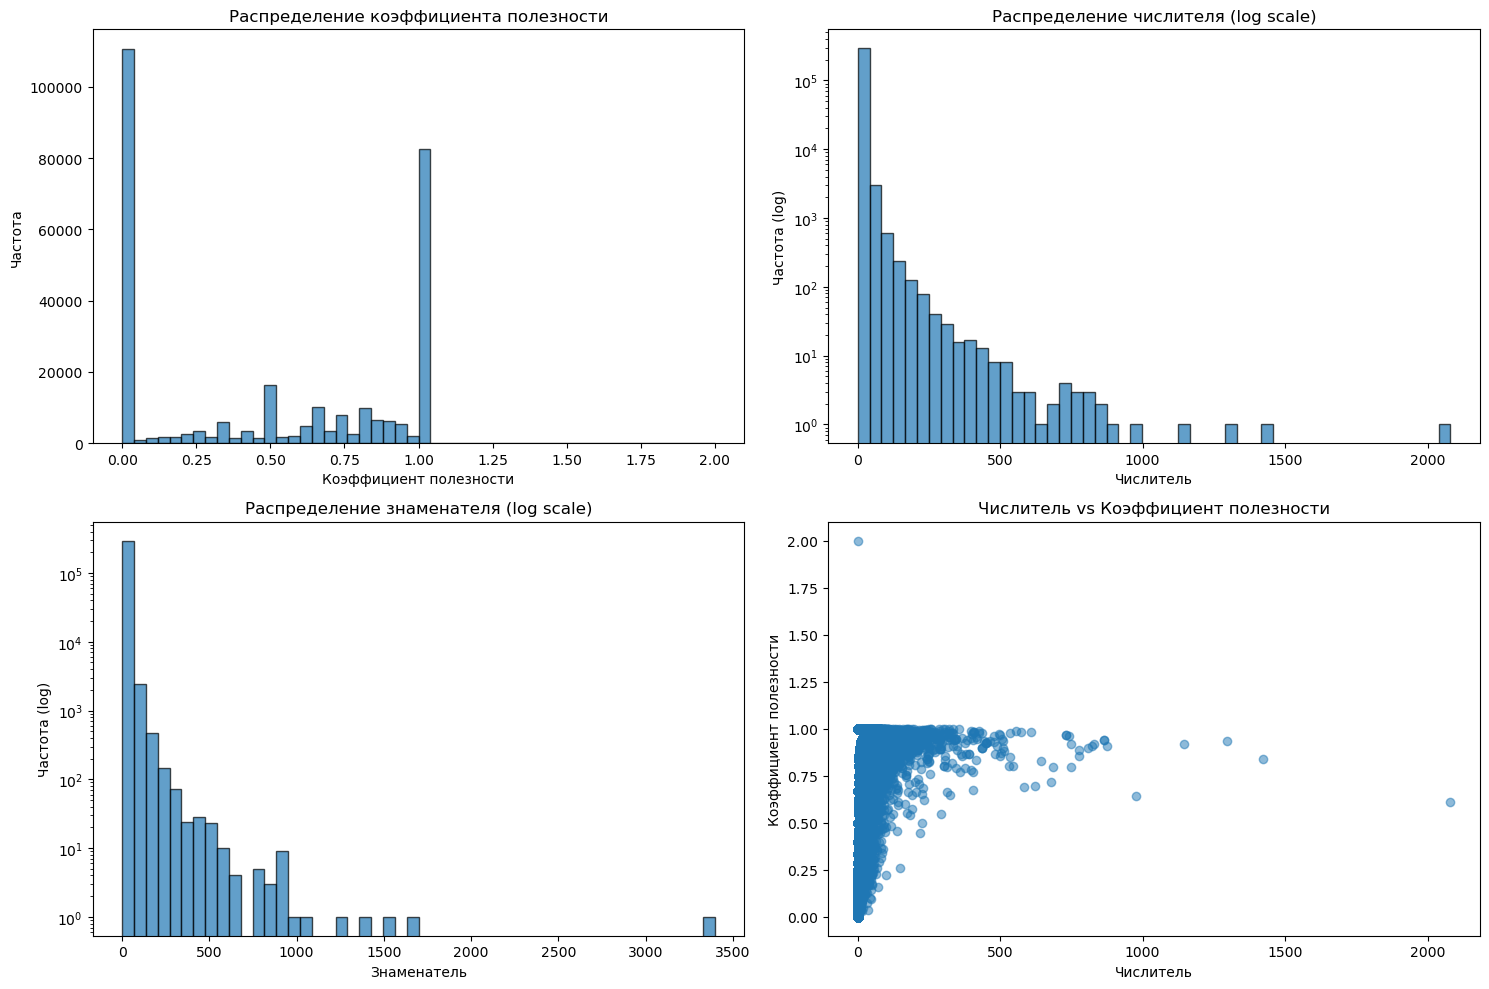

In [42]:
# Для визуализации возьмем sample данных
sample_df = df.sample(0.1).toPandas()

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Распределение helpfulness_ratio
axes[0, 0].hist(sample_df['helpfulness_ratio'].dropna(), bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Распределение коэффициента полезности')
axes[0, 0].set_xlabel('Коэффициент полезности')
axes[0, 0].set_ylabel('Частота')

# 2. Распределение числителя (логарифмическая шкала)
axes[0, 1].hist(sample_df['helpfulness_numerator'].dropna(), bins=50, alpha=0.7, edgecolor='black', log=True)
axes[0, 1].set_title('Распределение числителя (log scale)')
axes[0, 1].set_xlabel('Числитель')
axes[0, 1].set_ylabel('Частота (log)')

# 3. Распределение знаменателя (логарифмическая шкала)
axes[1, 0].hist(sample_df['helpfulness_denominator'].dropna(), bins=50, alpha=0.7, edgecolor='black', log=True)
axes[1, 0].set_title('Распределение знаменателя (log scale)')
axes[1, 0].set_xlabel('Знаменатель')
axes[1, 0].set_ylabel('Частота (log)')

# 4. scatter plot: числитель vs коэффициент
axes[1, 1].scatter(sample_df['helpfulness_numerator'], sample_df['helpfulness_ratio'], alpha=0.5)
axes[1, 1].set_title('Числитель vs Коэффициент полезности')
axes[1, 1].set_xlabel('Числитель')
axes[1, 1].set_ylabel('Коэффициент полезности')

plt.tight_layout()
plt.show()

#### Анализ столбца `review_time`

Данный столбец содержит информацию о временной метке отзыва и представляет собой **временной признак**. Проанализируем распределение меток и наличие пропущенных значений.

In [43]:
col_name = "review_time"
df.select(col_name).orderBy(col_name, ascending=False).show(10)
df.select(col_name).orderBy(col_name, ascending=True).show(10)

+-----------+
|review_time|
+-----------+
| 1362355200|
| 1362355200|
| 1362355200|
| 1362355200|
| 1362355200|
| 1362355200|
| 1362355200|
| 1362355200|
| 1362355200|
| 1362355200|
+-----------+
only showing top 10 rows

+-----------+
|review_time|
+-----------+
|         -1|
|         -1|
|         -1|
|         -1|
|         -1|
|         -1|
|         -1|
|         -1|
|         -1|
|         -1|
+-----------+
only showing top 10 rows



Статистика

In [44]:
# Базовая статистика
time_stats = df.select(
    count("review_time").alias("total"),
    mean("review_time").alias("avg"),
    stddev("review_time").alias("std"),
    mn("review_time").alias("min"),
    mx("review_time").alias("max"),
    count(when(col("review_time").isNull(), True)).alias("null_count")
).collect()[0]

print(f"Всего временных меток: {time_stats['total']:,}")
print(f"Пропущенных: {time_stats['null_count']:,} ({time_stats['null_count']/df.count()*100:.2f}%)")
print(f"Среднее значение: {time_stats['avg']:,.0f}")
print(f"Стандартное отклонение: {time_stats['std']:,.0f}")
print(f"Минимальная метка: {time_stats['min']}")
print(f"Максимальная метка: {time_stats['max']}")

Всего временных меток: 2,981,716
Пропущенных: 0 (0.00%)
Среднее значение: 1,132,098,842
Стандартное отклонение: 149,506,068
Минимальная метка: -1
Максимальная метка: 1362355200


Преобразование дат

In [45]:
from pyspark.sql.functions import (from_unixtime, year, date_format)

# Преобразуем timestamp в читаемые форматы
df_with_dates = df.withColumn(
    "review_date", 
    from_unixtime(col("review_time")).cast("date")
).withColumn(
    "review_datetime",
    from_unixtime(col("review_time"))
).withColumn(
    "review_year", 
    year(col("review_date"))
).withColumn(
    "review_month",
    date_format(col("review_date"), "yyyy-MM")
).withColumn(
    "review_day_of_week",
    date_format(col("review_date"), "EEEE")
)

# Проверяем преобразование
print("\n=== ПРИМЕРЫ ПРЕОБРАЗОВАННЫХ ДАТ ===")
df_with_dates.select(
    "review_time", 
    "review_datetime", 
    "review_date",
    "review_year",
    "review_month",
    "review_day_of_week"
).limit(10).show(truncate=False)


=== ПРИМЕРЫ ПРЕОБРАЗОВАННЫХ ДАТ ===
+-----------+-------------------+-----------+-----------+------------+------------------+
|review_time|review_datetime    |review_date|review_year|review_month|review_day_of_week|
+-----------+-------------------+-----------+-----------+------------+------------------+
|960768000  |2000-06-12 00:00:00|2000-06-12 |2000       |2000-06     |Monday            |
|1039564800 |2002-12-11 00:00:00|2002-12-11 |2002       |2002-12     |Wednesday         |
|1083974400 |2004-05-08 00:00:00|2004-05-08 |2004       |2004-05     |Saturday          |
|1222041600 |2008-09-22 00:00:00|2008-09-22 |2008       |2008-09     |Monday            |
|1354924800 |2012-12-08 00:00:00|2012-12-08 |2012       |2012-12     |Saturday          |
|932342400  |1999-07-19 00:00:00|1999-07-19 |1999       |1999-07     |Monday            |
|1036108800 |2002-11-01 00:00:00|2002-11-01 |2002       |2002-11     |Friday            |
|1204070400 |2008-02-27 00:00:00|2008-02-27 |2008       |2008-0

Анализ по годам

Количество отзывов по годам:
+-----------+------------+------------------+
|review_year|review_count|        avg_rating|
+-----------+------------+------------------+
|       1969|          21|3.3333333333333335|
|       1995|         267|4.5767790262172285|
|       1996|        6306| 4.639232477006026|
|       1997|       41772|4.5214018960068945|
|       1998|      123829| 4.352728359269638|
|       1999|      221301|4.2149515817822785|
|       2000|      223909| 4.220585148430835|
|       2001|      189156| 4.204630040812874|
|       2002|      183569| 4.161002129989268|
|       2003|      176248| 4.121970178385003|
|       2004|      177046|4.0933090835150185|
|       2005|      202671| 4.142418007509708|
|       2006|      190752|4.1771252726052674|
|       2007|      168218| 4.228245490970051|
|       2008|      141809| 4.204176039602564|
|       2009|      150702| 4.197946941646428|
|       2010|      157457| 4.176841931447951|
|       2011|      170297| 4.157078515769508|
|    

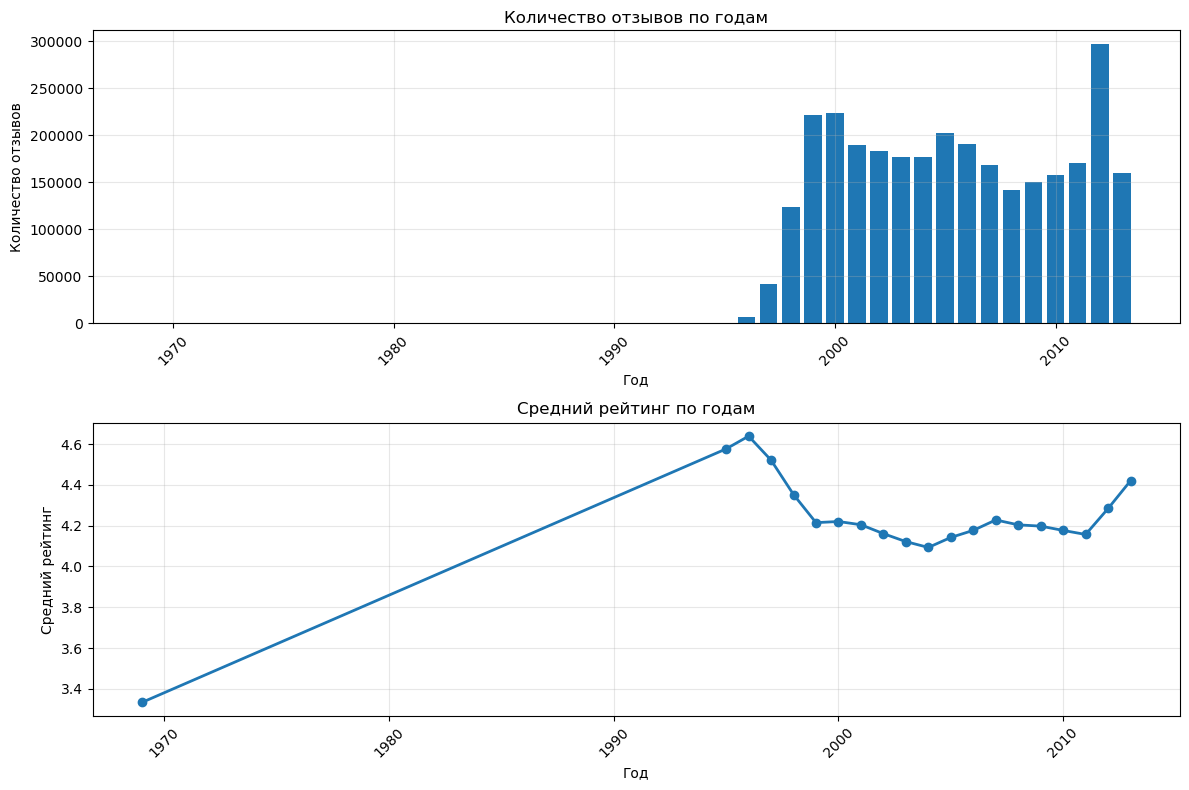

In [46]:
from pyspark.sql.functions import avg

yearly_stats = df_with_dates.filter(col("review_year").isNotNull()) \
    .groupBy("review_year") \
    .agg(
        count("*").alias("review_count"),
        avg("review_score").alias("avg_rating")
    ) \
    .orderBy("review_year")

print("Количество отзывов по годам:")
yearly_stats.show()

# Визуализация трендов
yearly_pd = yearly_stats.toPandas()

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.bar(yearly_pd['review_year'], yearly_pd['review_count'])
plt.title('Количество отзывов по годам')
plt.xlabel('Год')
plt.ylabel('Количество отзывов')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(yearly_pd['review_year'], yearly_pd['avg_rating'], marker='o', linewidth=2, markersize=6)
plt.title('Средний рейтинг по годам')
plt.xlabel('Год')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Анализ по месяцам

In [47]:
# Находим последний полный год с данными
last_year = yearly_pd[yearly_pd['review_count'] > 0]['review_year'].max()
print(f"Анализ за последний полный год: {last_year}")

monthly_stats = df_with_dates.filter(col("review_year") == last_year) \
    .groupBy("review_month") \
    .agg(
        count("*").alias("review_count"),
        avg("review_score").alias("avg_rating")
    ) \
    .orderBy("review_month")

print(f"Распределение по месяцам за {last_year} год:")
monthly_stats.show()

# Сезонность по месяцам (все годы)
monthly_all_years = df_with_dates.filter(col("review_month").isNotNull()) \
    .withColumn("month_only", substring(col("review_month"), 6, 2)) \
    .groupBy("month_only") \
    .agg(
        count("*").alias("review_count"),
        avg("review_score").alias("avg_rating")
    ) \
    .orderBy("month_only")

print("Сезонность по месяцам (все годы):")
monthly_all_years.show()

Анализ за последний полный год: 2013
Распределение по месяцам за 2013 год:
+------------+------------+------------------+
|review_month|review_count|        avg_rating|
+------------+------------+------------------+
|     2013-01|       91892| 4.430559787576721|
|     2013-02|       64978|4.4067068854073685|
|     2013-03|        2866| 4.417306350314027|
+------------+------------+------------------+

Сезонность по месяцам (все годы):
+----------+------------+------------------+
|month_only|review_count|        avg_rating|
+----------+------------+------------------+
|        01|      346281| 4.258056318423477|
|        02|      281299| 4.242144479717312|
|        03|      243540| 4.210462347047713|
|        04|      220485| 4.196185681565639|
|        05|      228091| 4.202305220284886|
|        06|      223475| 4.188405861953239|
|        07|      230181| 4.188269231604694|
|        08|      229516| 4.181181268408302|
|        09|      223872| 4.185092374213837|
|        10|      238

Анализ по неделям

In [48]:
day_of_week_stats = df_with_dates.filter(col("review_day_of_week").isNotNull()) \
    .groupBy("review_day_of_week") \
    .agg(
        count("*").alias("review_count"),
        avg("review_score").alias("avg_rating")
    )

# Сортируем по порядку дней недели
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_of_week_stats = day_of_week_stats \
    .withColumn("day_order", 
        when(col("review_day_of_week") == "Monday", 1)
        .when(col("review_day_of_week") == "Tuesday", 2)
        .when(col("review_day_of_week") == "Wednesday", 3)
        .when(col("review_day_of_week") == "Thursday", 4)
        .when(col("review_day_of_week") == "Friday", 5)
        .when(col("review_day_of_week") == "Saturday", 6)
        .when(col("review_day_of_week") == "Sunday", 7)
    ) \
    .orderBy("day_order")

print("Распределение по дням недели:")
day_of_week_stats.select("review_day_of_week", "review_count", "avg_rating").show()

Распределение по дням недели:
+------------------+------------+-----------------+
|review_day_of_week|review_count|       avg_rating|
+------------------+------------+-----------------+
|            Monday|      461105|4.200156146647727|
|           Tuesday|      459371|4.206663024004563|
|         Wednesday|      452162|4.210851420508579|
|          Thursday|      444837|4.209045110905793|
|            Friday|      413257|4.221184396150579|
|          Saturday|      360936|4.239014672961411|
|            Sunday|      390048|4.219485806875051|
+------------------+------------+-----------------+



Анализ временных паттернов

In [49]:
# Период покрытия данных
date_range = df_with_dates.select(
    mn("review_date").alias("first_review"),
    mx("review_date").alias("last_review")
).collect()[0]

print(f"Период покрытия данных:")
print(f"Первый отзыв: {date_range['first_review']}")
print(f"Последний отзыв: {date_range['last_review']}")

# Количество дней с отзывами
days_with_reviews = df_with_dates.select("review_date").distinct().count()
total_days = (date_range['last_review'] - date_range['first_review']).days

print(f"Дней с отзывами: {days_with_reviews} из {total_days} ({days_with_reviews/total_days*100:.1f}%)")

# Самые активные дни
most_active_days = df_with_dates.groupBy("review_date") \
    .agg(count("*").alias("daily_reviews")) \
    .orderBy(desc("daily_reviews"))

print("\nСамые активные дни по количеству отзывов:")
most_active_days.limit(10).show()

# Среднее количество отзывов в день
avg_daily_reviews = df_with_dates.groupBy("review_date") \
    .agg(count("*").alias("daily_reviews")) \
    .select(mean("daily_reviews").alias("avg_daily_reviews")) \
    .collect()[0][0]

print(f"Среднее количество отзывов в день: {avg_daily_reviews:.1f}")

Период покрытия данных:
Первый отзыв: 1969-12-31
Последний отзыв: 2013-03-04
Дней с отзывами: 6272 из 15769 (39.8%)

Самые активные дни по количеству отзывов:
+-----------+-------------+
|review_date|daily_reviews|
+-----------+-------------+
| 2012-09-06|         5217|
| 2013-02-18|         4336|
| 2012-12-19|         4003|
| 2013-01-04|         3943|
| 2007-01-09|         3848|
| 2012-12-28|         3765|
| 2012-12-27|         3708|
| 2013-01-08|         3637|
| 2013-01-02|         3539|
| 2012-12-26|         3524|
+-----------+-------------+

Среднее количество отзывов в день: 475.4


Анализ корреляции времени с другими метриками

In [50]:
from pyspark.sql.functions import datediff

# Создаем числовые представления для корреляции
df_for_corr = df_with_dates.withColumn(
    "days_since_epoch", 
    datediff(col("review_date"), lit("1970-01-01"))
)

# Вычисляем корреляции
corr_time_rating = df_for_corr.stat.corr("days_since_epoch", "review_score")
corr_time_helpfulness = df_for_corr.stat.corr("days_since_epoch", "helpfulness_ratio")

print(f"Корреляция даты отзыва с оценкой: {corr_time_rating:.3f}")
print(f"Корреляция даты отзыва с полезностью: {corr_time_helpfulness:.3f}")

# Анализ изменения оценок со временем
print("\nТЕНДЕНЦИИ ИЗМЕНЕНИЯ ОЦЕНОК:")
yearly_rating_trend = df_with_dates.filter(col("review_year").isNotNull()) \
    .groupBy("review_year") \
    .agg(
        count("*").alias("review_count"),
        avg("review_score").alias("avg_rating"),
        avg("helpfulness_ratio").alias("avg_helpfulness")
    ) \
    .orderBy("review_year")

print("Динамика оценок и полезности по годам:")
yearly_rating_trend.show()

Корреляция даты отзыва с оценкой: 0.008
Корреляция даты отзыва с полезностью: -0.226

ТЕНДЕНЦИИ ИЗМЕНЕНИЯ ОЦЕНОК:
Динамика оценок и полезности по годам:
+-----------+------------+------------------+-------------------+
|review_year|review_count|        avg_rating|    avg_helpfulness|
+-----------+------------+------------------+-------------------+
|       1969|          21|3.3333333333333335| 0.8115646258503402|
|       1995|         267|4.5767790262172285|0.44341022915499356|
|       1996|        6306| 4.639232477006026|  0.465245666021079|
|       1997|       41772|4.5214018960068945| 0.4146272038892364|
|       1998|      123829| 4.352728359269638| 0.4008125973599951|
|       1999|      221301|4.2149515817822785|0.45088636240935087|
|       2000|      223909| 4.220585148430835| 0.6357512527930188|
|       2001|      189156| 4.204630040812874| 0.6158507133307956|
|       2002|      183569| 4.161002129989268| 0.6032125703906795|
|       2003|      176248| 4.121970178385003| 0.6077498

#### Анализ столбца `authors`

Данный столбец содержит информацию об авторах книг и представляет собой **категориальный признак**. Проанализируем распределение авторов и наличие пропущенных значений.

In [51]:
count_nulls(data=df, column_name="authors")

Число колонок с NULL: 0 (0.00%)


Видно, что пропуски в данном столбце присутствуют/отсутствуют (зависит от результата).

Проанализируем распределение авторов

Количество категорий признака authors: 132650


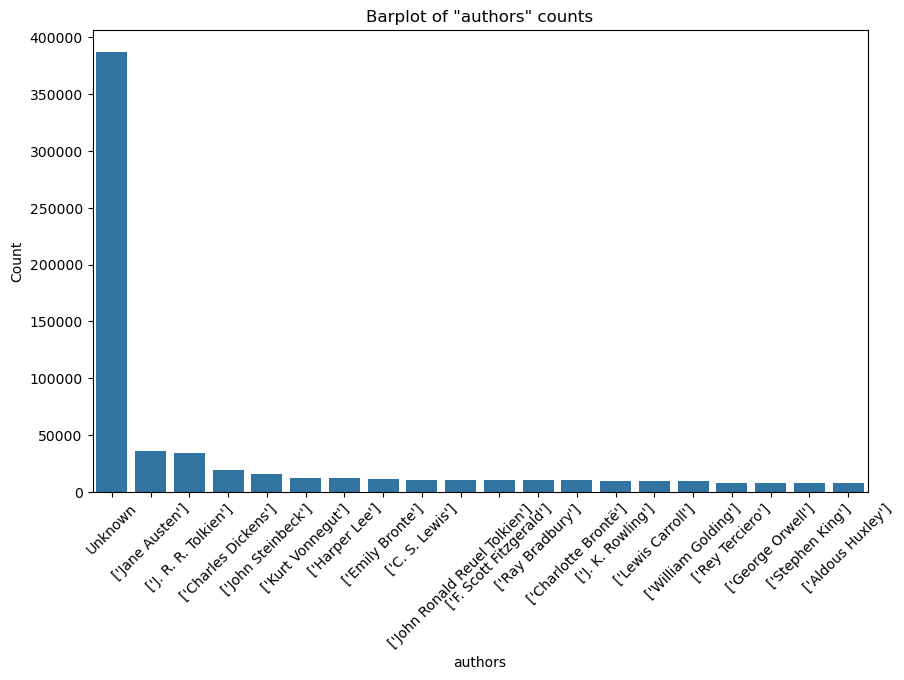

In [52]:
plot_cat_distribution(data=df, column_name="authors", top_n=20)

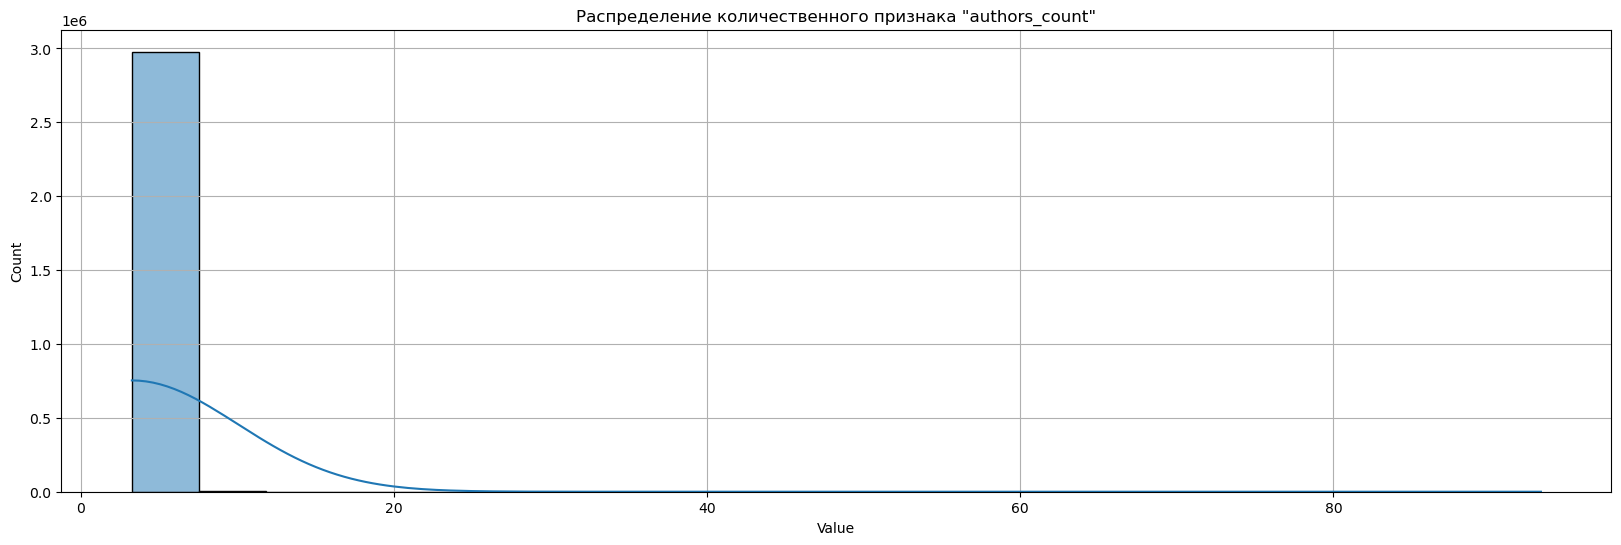

In [53]:
# Посмотрим на статистику по количеству авторов на книгу
from pyspark.sql.functions import split, size, stddev

df_with_authors_count = df.withColumn("authors_count", size(split(col("authors"), ",")))
plot_quant_distribution(data=df_with_authors_count, column="authors_count", num_bins=20)

Статистика по количеству авторов

In [54]:
print("Топ-15 авторов по количеству книг:")
(
    df
    .groupBy("authors")
    .count()
    .orderBy("count", ascending=False)
    .withColumnRenamed("count", "books_count")
    .show(15, truncate=False)
)

Топ-15 авторов по количеству книг:
+-----------------------------+-----------+
|authors                      |books_count|
+-----------------------------+-----------+
|Unknown                      |386880     |
|['Jane Austen']              |35756      |
|['J. R. R. Tolkien']         |34703      |
|['Charles Dickens']          |19824      |
|['John Steinbeck']           |16279      |
|['Kurt Vonnegut']            |12076      |
|['Harper Lee']               |11964      |
|['Emily Bronte']             |11729      |
|['C. S. Lewis']              |11005      |
|['John Ronald Reuel Tolkien']|10382      |
|['F. Scott Fitzgerald']      |10336      |
|['Ray Bradbury']             |10282      |
|['Charlotte Brontë']         |10196      |
|['J. K. Rowling']            |9950       |
|['Lewis Carroll']            |9812       |
+-----------------------------+-----------+
only showing top 15 rows



Проверим наличие книг без указания автора (NULL или пустые строки)

In [55]:
df.filter(col("authors").isNull() | (col("authors") == "") | (col("authors") == "[]")).count()

0

#### Анализ столбца `publisher`

Данный столбец содержит информацию об издательствах книг и представляет собой **категориальный признак**. Проверим наличие пропущенных значений и проанализируем распределение издательств.

In [56]:
count_nulls(data=df, column_name="publisher")

Число колонок с NULL: 0 (0.00%)


Видно, что пропуски в данном столбце присутствуют/отсутствуют (зависит от результата).

Количество категорий признака publisher: 34058


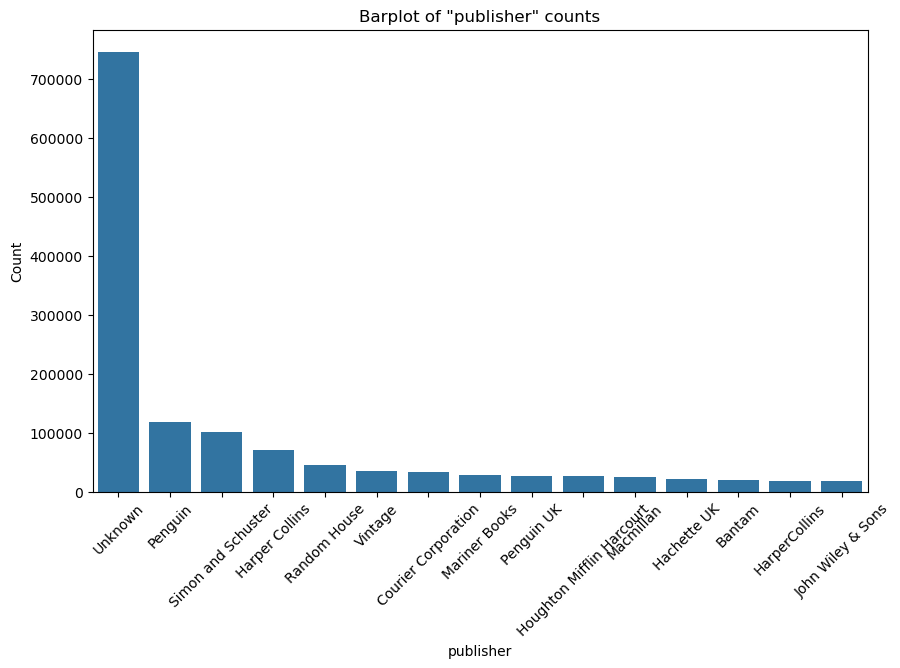

In [57]:
plot_cat_distribution(data=df, column_name="publisher", top_n=15)

In [58]:
print("Общая статистика по издательствам:")
print(f"Уникальных издательств: {df.select('publisher').distinct().count()}")
print(f"Количество записей с указанным издательством: {df.filter(col('publisher').isNotNull()).count()}")

Общая статистика по издательствам:
Уникальных издательств: 34058
Количество записей с указанным издательством: 2981716


In [59]:
print("Топ-10 издательств по количеству книг:")
(
    df
    .groupBy("publisher")
    .count()
    .orderBy("count", ascending=False)
    .withColumnRenamed("count", "books_count")
    .show(10, truncate=False)
)

Топ-10 издательств по количеству книг:
+-------------------------+-----------+
|publisher                |books_count|
+-------------------------+-----------+
|Unknown                  |745758     |
|Penguin                  |118788     |
|Simon and Schuster       |101314     |
|Harper Collins           |70051      |
|Random House             |44770      |
|Vintage                  |34771      |
|Courier Corporation      |32812      |
|Mariner Books            |27525      |
|Penguin UK               |26666      |
|Houghton Mifflin Harcourt|26594      |
+-------------------------+-----------+
only showing top 10 rows



#### Анализ столбца `published_date`

Данный столбец содержит даты публикации книг и представляет собой **временной признак**. Проанализируем распределение дат и наличие пропущенных значений.

In [60]:
count_nulls(data=df, column_name="published_date")

Число колонок с NULL: 355296 (11.92%)


Видно, что пропуски в данном столбце присутствуют/отсутствуют (зависит от результата).

Посмотрим на различные форматы дат в данных

In [61]:
print("Примеры различных форматов дат:")
df.select("published_date").distinct().orderBy("published_date").show(20, truncate=False)

Примеры различных форматов дат:
+--------------------------------------------------------------------------------------------------------------------------+
|published_date                                                                                                            |
+--------------------------------------------------------------------------------------------------------------------------+
|NULL                                                                                                                      |
| "" ""Cruising for Prostitutes                                                                                            |
| "" accompanied by illustrations of various animals."                                                                     |
| "" and ""In the Old South."""                                                                                            |
| "" and ""Tawny                                                                             

Преобразуем даты в год публикации для анализа

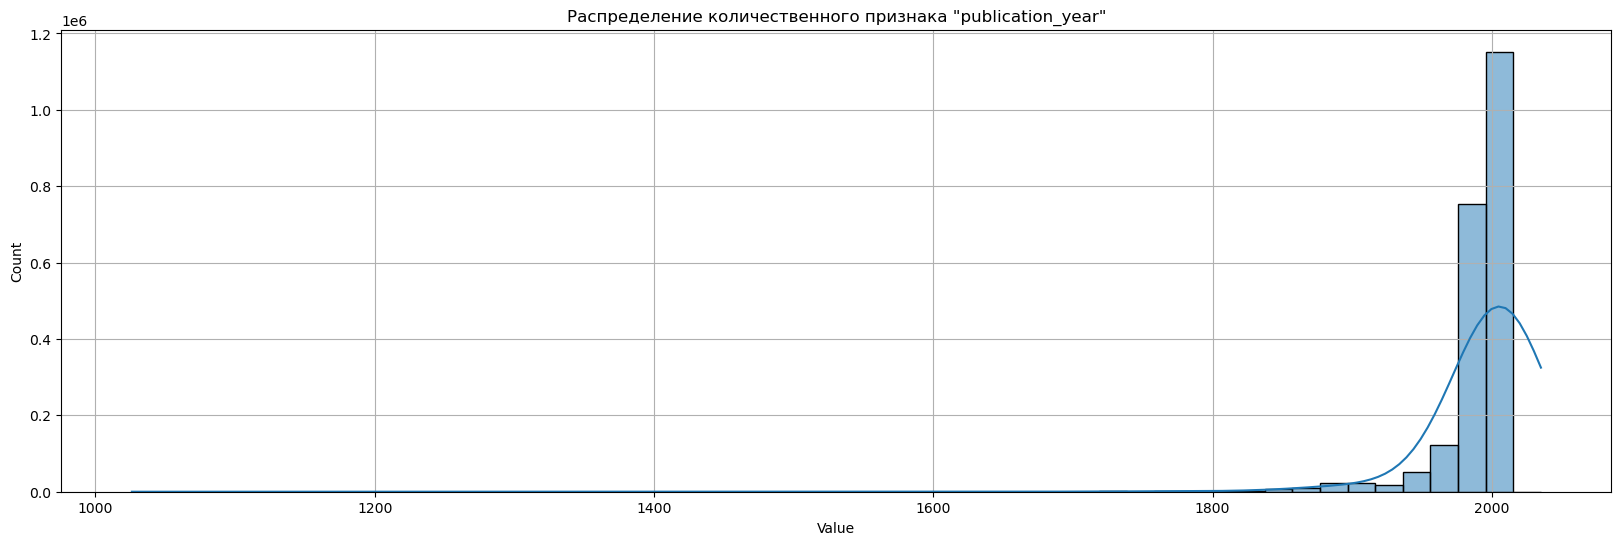

In [62]:
from pyspark.sql.functions import year, from_unixtime, to_date

# Извлекаем год из различных форматов дат
df_with_year = df.withColumn(
    "publication_year",
    when(col("published_date").rlike(r"^\d{4}$"), col("published_date").cast("int"))  # только год
    .when(col("published_date").rlike(r"^\d{4}-\d{2}-\d{2}$"), year(to_date(col("published_date"), "yyyy-MM-dd")))  # YYYY-MM-DD
    .when(col("published_date").rlike(r"^\d+$"), year(from_unixtime(col("published_date").cast("long"))))  # timestamp
    .otherwise(None)
)

# Анализ распределения годов публикации
plot_quant_distribution(data=df_with_year.filter(col("publication_year").isNotNull()), column="publication_year", num_bins=50)

Статистика по годам публикации

In [63]:
print("Топ-10 годов по количеству опубликованных книг:")
(
    df_with_year
    .filter(col("publication_year").isNotNull())
    .groupBy("publication_year")
    .count()
    .orderBy("count", ascending=False)
    .withColumnRenamed("count", "books_count")
    .show(10, truncate=False)
)

Топ-10 годов по количеству опубликованных книг:
+----------------+-----------+
|publication_year|books_count|
+----------------+-----------+
|2012            |127995     |
|2009            |97424      |
|2010            |88255      |
|2014            |86023      |
|2003            |85042      |
|2011            |84211      |
|2005            |78402      |
|2001            |73133      |
|2013            |70770      |
|2002            |70218      |
+----------------+-----------+
only showing top 10 rows



#### Анализ столбца `categories`

Данный столбец содержит категории/жанры книг и представляет собой **категориальный признак**. Проанализируем распределение категорий и их влияние на рейтинги.

In [64]:
# Проверим категории с самыми противоречивыми отзывами (высокое стандартное отклонение)
print("Категории с самыми противоречивыми оценками:")
print_df(
    df
    .filter(col("categories").isNotNull())
    .groupBy("categories")
    .agg(
        mean("review_score").alias("avg_rating"),
        count("Id").alias("books_count"),
        stddev("review_score").alias("rating_std")
    )
    .filter("books_count >= 20")  # только категории с 20+ книгами
    .orderBy("rating_std", ascending=False)
)

Категории с самыми противоречивыми оценками:


,categories,avg_rating,books_count,rating_std
0,"like restaurants and other points of interest in the area of his visits! From """"Fire Under the Bridge"""" (Engine 205/Ladder 118",3.13,23,2.01
1,"Philadelphia """"As simultaneously mysticism and fact",3.50,24,1.98
2,['Creationism'],3.38,26,1.96
3,2001-05-12,3.30,30,1.93
4,and perspectives that can help you achieve your breakthrough (major) life goals. These include: time management skills and the 80/20 rule; looking for greener pastures; showcasing your talents (visibility → opportunities); committing to never-ending improvements in performance,2.45,20,1.93
5,http://books.google.com/books?id=9Z39MAAACAAJ&dq=Permission+To+Succeed&hl=&source=gbs_api,3.58,33,1.92
6,['David Aikman'],3.00,36,1.91
7,Eckankar does not agree with Lane's ﬁndings. However,3.28,25,1.90
8,"coworker or friend. Makes a great employee appreciation gifts for women.This can be the best choose for paperbacks with 120 Pages / 6"""" x 9"""".""",3.17,24,1.90
9,http://books.google.nl/books?id=lU9angEACAAJ&dq=What+Love+Is+This%3F+Calvinism%27s+Misrepresentation+of+God&hl=&cd=1&source=gbs_api,3.07,156,1.90


In [65]:
count_nulls(data=df, column_name="categories")

Число колонок с NULL: 0 (0.00%)


In [66]:
print_df(df.filter(col("categories").isNull()))

,id,title,authors,publisher,published_date,categories,review_score,review_text,review_summary,review_helpfulness,review_time,user_id,profile_name,helpfulness_numerator,helpfulness_denominator,helpfulness_ratio,published_date_clean,authors_array,categories_array,published_year


#### Создание бинарных признаков и доп. полей для моделей

In [67]:
# Создаем бинарные признаки
from pyspark.sql.types import DoubleType, IntegerType
from pyspark.sql.functions import length, size, month, lower

# Сначала создаем колонки author_count и category_count
df = df.withColumn("author_count", size(col("authors_array")))
df = df.withColumn("category_count", size(col("categories_array")))

# Бинаризация helpfulness_ratio
df = df.withColumn("is_helpful", 
    when(col("helpfulness_ratio") > 0.5, 1).otherwise(0))

# Бинаризация author_count
df = df.withColumn("has_multiple_authors",
    when(col("author_count") > 1, 1).otherwise(0))

# Бинаризация category_count
df = df.withColumn("has_multiple_categories",
    when(col("category_count") > 2, 1).otherwise(0))

# Бинаризация review_time (используем реалистичный порог)
# Найдем 75-й перцентиль для review_time
review_time_threshold = df.approxQuantile("review_time", [0.75], 0.01)[0]
df = df.withColumn("is_recent_review",
    when(col("review_time") > review_time_threshold, 1).otherwise(0))

df = df.withColumn("helpfulness_ratio", col("helpfulness_ratio").cast(DoubleType()))
df = df.withColumn("is_helpful", col("is_helpful").cast(IntegerType()))

df = df.withColumn("review_text_length", length("review_text"))
df = df.withColumn("review_summary_length", length("review_summary"))
df = df.withColumn("title_length", length("title"))

# Извлекаем год и месяц из review_time
df = df.withColumn("review_year", year(from_unixtime("review_time")))
df = df.withColumn("review_month", month(from_unixtime("review_time")))

df = df.withColumn("publisher_type", 
                   when(col("publisher").isNull() | 
                          (col("publisher") == "Unknown Publisher"), "unknown")
                    .when(col("publisher").isin(["Penguin", "Vintage", "Harper", "Random House", "Oxford"]), "major")
                    .otherwise("other"))

df = df.withColumn("main_category", 
                   when(lower(col("categories")).contains("fiction"), "fiction")
                    .when(lower(col("categories")).contains("non") | 
                          lower(col("categories")).contains("biography"), "non_fiction")
                    .when(lower(col("categories")).contains("children") | 
                          lower(col("categories")).contains("kids"), "children")
                    .otherwise("other"))

df.printSchema()
print_df(df)

root
 |-- id: string (nullable = true)
 |-- title: string (nullable = true)
 |-- authors: string (nullable = true)
 |-- publisher: string (nullable = true)
 |-- published_date: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- review_score: double (nullable = true)
 |-- review_text: string (nullable = true)
 |-- review_summary: string (nullable = true)
 |-- review_helpfulness: string (nullable = true)
 |-- review_time: integer (nullable = true)
 |-- user_id: string (nullable = true)
 |-- profile_name: string (nullable = true)
 |-- helpfulness_numerator: integer (nullable = true)
 |-- helpfulness_denominator: integer (nullable = true)
 |-- helpfulness_ratio: double (nullable = true)
 |-- published_date_clean: date (nullable = true)
 |-- authors_array: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- categories_array: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- published_year: integer (nullable = true)
 |-

,id,title,authors,publisher,published_date,categories,review_score,review_text,review_summary,review_helpfulness,review_time,user_id,profile_name,helpfulness_numerator,helpfulness_denominator,helpfulness_ratio,published_date_clean,authors_array,categories_array,published_year,author_count,category_count,is_helpful,has_multiple_authors,has_multiple_categories,is_recent_review,review_text_length,review_summary_length,title_length,review_year,review_month,publisher_type,main_category
0,1891882007,"""""""Breaking Traditions"""" Cathedral Windows Quick Method Quilt""","['Susan Tedrow Fisher', 'Kimberly Nappier']",Unknown,1999,['Patchwork'],4.00,"This is an interesting twist on a time-honored quilt pattern. Although I have always liked the cathedral windows pattern, I have always resisted making one due to the tremendous amount of hand sewing. This book allows you to create a beautiful quilt using machine techniques. The instructions are brief, to-the-point and clear. The illustrations appear to be hand-drawn, but they serve to explain the process and do not detract from the text. The net result is a beautiful old-style quilt streamlined for those of us who do not have the time to create it all by hand. My next full-sized project will be a cathedral window quilt.",Breaking traditions cathedral windows quick method quilt,59/61,960768000,A124LUSIP65B1U,School Librarian,59,61,0.97,None,"['Susan Tedrow Fisher', 'Kimberly Nappier']",['Patchwork'],0,2,1,1,1,0,0,628,56,62,2000,6,other,other
1,1891882007,"""""""Breaking Traditions"""" Cathedral Windows Quick Method Quilt""","['Susan Tedrow Fisher', 'Kimberly Nappier']",Unknown,1999,['Patchwork'],3.00,"""This is not a book. It is 12 pages of instructions with hand drawn illustrations of the block units. If all you want are instructions on """"How to"""" make a traditional Cathedral Window block",Quick & Easy Instruction Sheet,31/32,1039564800,A3Q54OUHBC872L,"""G. W. Coleman """"IT Specialist""""""",31,32,0.97,None,"['Susan Tedrow Fisher', 'Kimberly Nappier']",['Patchwork'],0,2,1,1,1,0,0,190,30,62,2002,12,other,other
2,1891882007,"""""""Breaking Traditions"""" Cathedral Windows Quick Method Quilt""","['Susan Tedrow Fisher', 'Kimberly Nappier']",Unknown,1999,['Patchwork'],1.00,"The price of this book is about 8 times what it is worth. First of all, it is not a ""paperback""; it is a ""pamphlet"". There is no firm cover or back. I feel taken advantage of when I order a book expecting a book and get a pamphlet. Some pages held together and called a ""paperback""!!!!!!!!!!!!!!!!!!!!",Got to be kidding,18/20,1083974400,A3AY8G2GT95RHL,Jacqueline Rund,18,20,0.90,None,"['Susan Tedrow Fisher', 'Kimberly Nappier']",['Patchwork'],0,2,1,1,1,0,0,331,17,62,2004,5,other,other
3,1891882007,"""""""Breaking Traditions"""" Cathedral Windows Quick Method Quilt""","['Susan Tedrow Fisher', 'Kimberly Nappier']",Unknown,1999,['Patchwork'],5.00,"""I loved this """"book."""" The directions are excellent. The drawings are precise and provide the perfect compliment to the written directions. If you've ever wanted to make a cathedral window quilt",Horse Rider,1/1,1222041600,A1DV53Z7XEJEY7,"""Horse Rider """"ET""""""",1,1,1.00,None,"['Susan Tedrow Fisher', 'Kimberly Nappier']",['Patchwork'],0,2,1,1,1,0,0,195,11,62,2008,9,other,other
4,B000PH26B4,"""""""Dear America"""" Four Volume Boxed Set (Dear America)""",Dear America: Standing in the Light,['Scholastic Books'],None,Unknown,5.00,my daughter will be so surprised on christmas morning and im so glad i found what i was looking for for such a good price. I recieved it and its perfect!,happy,0/0,1354924800,A2D99F1RC3ZCVI,cindy bancroft,0,0,0.00,None,[' Dear America: Standing in the Light'],None,0,1,-1,0,0,0,1,153,5,55,2012,12,other,other
5,0898702755,"""""""Forget Not Love"""": The Passion of Maximilian Kolbe""",['André Frossard'],Ignatius Press,1991,['Religion'],5.00,"""Forget Not Love"" is the story of St. Maximilian Kolbe, the Polish Franciscan who offered to die in the p

#### Сохранение данных

Сохраняет подготовленные данные на диск.

In [68]:
database_name = "vasilev_database"
table_name = "books_table_past_exp"

output_path = f"hdfs://namenode:9000/b/{database_name}/{table_name}"

print(f"Сохраняем данные в: {output_path}")

df.write.mode("overwrite").option("compression", "snappy").parquet(output_path)

print("Данные успешно сохранены в Parquet формате в HDFS")

Сохраняем данные в: hdfs://namenode:9000/b/vasilev_database/books_table_past_exp
Данные успешно сохранены в Parquet формате в HDFS


Останавливаем `Spark`-сессию.

In [69]:
spark.stop()

Видно, что пропуски в данном столбце присутствуют/отсутствуют (зависит от результата).